# Titanic - Machine Learning from Diaster

**项目介绍**：

本项目基于 Kaggle 经典数据集 Titanic: Machine Learning from Disaster，目标是预测乘客是否在沉船事故中幸存。训练集包含819条数据，测试集包含418条数据。本项目最终对测试集的预测准确率为82.775%，该预测准确率在Kaggle排名前1%。


## 明确问题

- 目标：预测乘客是否幸存（Survived=0/1）
- 二分类问题（classification）
- 评价指标：准确率（Accuracy）、F1-score、AUC-ROC 等

### 项目思路

![Models](model_flowchart.png)

对数据集进行特征工程后，利用KNN模型对整个训练集进行训练，得到初步的预测值。在此基础上，对数据进行分组，分为Man, Boy, Not Single Woman和Single Woman四组，对Man和Single Woman对应的数据进行单独训练以提升预测准确率，将其预测结果与初步预测中Boy和Not Single Woman得到的预测结果进行合并得到总体的预测值。

## 获取数据

数据来自 Kaggle Titanic 数据集：
- train.csv（有标签）
- test.csv（无标签，需要提交预测结果）
- truth.csv（测试集的标签）

In [731]:
import numpy as np
import pandas as pd
import seaborn.objects as so
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from scipy.stats import trim_mean, median_abs_deviation
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt

首先导入数据，导入训练集和测试集，保留target。测试集中没有target，那么先补充Nan值

In [732]:
train = pd.read_csv('titanic/train.csv')
test = pd.read_csv('titanic/test.csv')
truth = pd.read_csv('titanic/truth.csv')

test['Survived'] = np.nan

total = pd.concat([train, test], ignore_index=True)

print(f"训练集结构:{train.shape}")
print(f"测试集结构:{test.shape}")

训练集结构:(891, 12)
测试集结构:(418, 12)


In [733]:
# 了解数据集
total.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,891.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,0.383838,2.294882,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.486592,0.837836,14.413493,1.041658,0.865560,51.758668
min,1.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,1.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,1.000000,3.000000,80.000000,8.000000,9.000000,512.329200


利用`describe`获取数据的整体统计信息:
1. Survived：本数据集的target，二元分类数据。key = 0, 1
2. PassengerId：乘客的身份id 唯一值 离散型数据
3. Pclass：乘客的Ticket class（票务等级）， key = 1， 2，3 （一等，二等，三等）
4. Name：乘客的姓名， 字符串类型 unstructured data
5. Sex：乘客的性别，二元分类数据，key = male, female
6. Age：年龄，数值型数据，连续型数据
7. Sibsp：泰坦尼克号上的兄弟姐妹/配偶数量， 数值型数据，离散型数据
8. Parch：泰坦尼克号上父母/孩子的数量，数值型数据，离散型数据
9. Ticket：车票号码
10. Fare：票价，数值型数据，连续型数据
11. Cabin：客舱号 /房间号
12. Embarked：起运港，分类数据。key = S, C, Q

**总结：**
1. 离散值数据有：Sibsp, Parch, Ticket
2. 分类数据有：Pclass, Sex, Cabin, Embarked
3. 具有唯一的数据有：PassengerId, Name
4. 连续型数据有：Age, Fare

In [734]:
total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


由information得到，数据中具有缺失值的特征有：Age, Fare, Cabin, Embarked。

接下来先对缺失值填充，再进行探索性数据分析

## 探索性数据分析（EDA）

### 缺失值

从第一部分已经得知，数据中有缺失值的特征有：Age, Fare, Cabin, Embarked

进一步地分析在训练集和测试集中有缺失值的特征

从结果可得：
- 训练集（train）：Age, Cabin, Embarked有缺失值
- 测试集（test）：Age, Fare, Cabin 有缺失值

首先分析有缺失值的特征


In [735]:
# 训练集的特征信息
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [736]:
# 测试集的特征信息
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
 11  Survived     0 non-null      float64
dtypes: float64(3), int64(4), object(5)
memory usage: 39.3+ KB


#### Age 填充

这里的Age有两种填充方法：
1. 找到Age与Pclass和Sex的关系，根据票舱等级和性别进行填充
2. 提取Title, 根据Title分组填充

首先计算数据的集中趋势和离散程度

In [737]:
mean = total['Age'].mean()
tmean = trim_mean(total['Age'].dropna(), 0.1)
median = total['Age'].median()
std = total['Age'].std()

# 中位数绝对偏差
mad = median_abs_deviation(total['Age'].dropna())

# 四分位距
iqr = total['Age'].quantile(0.75) - total['Age'].quantile(0.25)

# 百分位数
per = total['Age'].quantile([0.25, 0.5, 0.75])

print(f"Age平均值:{mean:.2f}")
print(f"Age切尾平均值:{tmean:.2f}")
print(f"中位数: {median:.2f}")
print(f"标准差:{std:.2f}")
print(f"中位数平均偏差:{mad:.2f}")
print(f"四分位距:{iqr:.2f}")
print("百分位数:")
print(per)

Age平均值:29.88
Age切尾平均值:29.39
中位数: 28.00
标准差:14.41
中位数平均偏差:8.00
四分位距:18.00
百分位数:
0.25    21.0
0.50    28.0
0.75    39.0
Name: Age, dtype: float64


探索Age的数据分布，可以从Age的箱线图看出，最小值约为0岁，最大值约为80岁，中位数为28岁，25百分位数为21岁，75百分位数为39岁。其中超出65岁左右的为异常值，数据中有一定数量的异常值，可以找出这些异常值。

<Axes: >

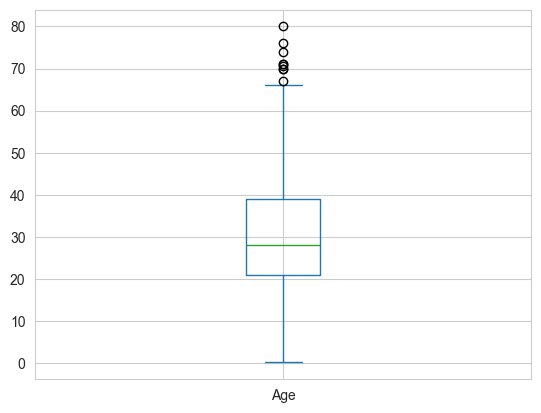

In [738]:
# Age的箱线图
total['Age'].plot.box()

In [739]:
# Age 频数表
ages = pd.cut(total['Age'], bins=8)
ages.value_counts(sort=False).reset_index(name='counts')

,Age,counts
0,"(0.0902, 10.149]",86
1,"(10.149, 20.128]",162
2,"(20.128, 30.106]",361
3,"(30.106, 40.085]",210
4,"(40.085, 50.064]",132
5,"(50.064, 60.043]",62
6,"(60.043, 70.021]",27
7,"(70.021, 80.0]",6


Text(0.5, 0, 'Age')

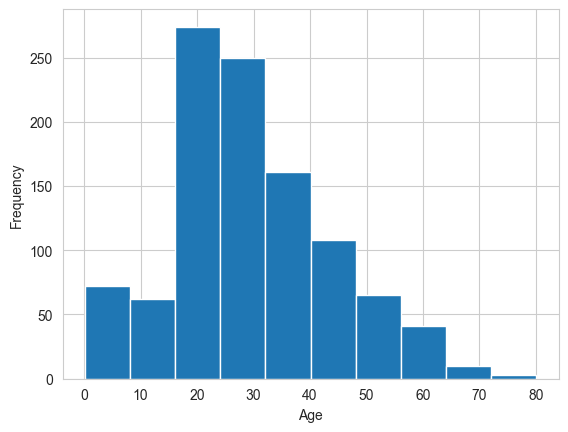

In [740]:
# 绘制Age直方图
ax = total['Age'].plot.hist()
ax.set_xlabel("Age")

Age的直方图显示Age并不是完全的正态分布，我们要更精确填充缺失值应该使用中位数。但是直接使用全数据集的中位数，仍然不够精确。我们可以进一步探索数据集中其他列与Age的相关性

In [741]:
age_corr = total.corrwith(total['Age'], numeric_only=True)
age_corr

PassengerId    0.028814
Survived      -0.077221
Pclass        -0.408106
Age            1.000000
SibSp         -0.243699
Parch         -0.150917
Fare           0.178740
dtype: float64

对只有数值的特征计算其与Age的相关程度，其中Pclass与Age相关程度相对较高。除此以外，仍有其他字符串数据未能计算与Age之间的联系，其中Sex可以作为Age的分组，进一步探索性别与年龄之间的联系

In [742]:
age_class_sex = total.groupby(['Pclass','Sex'])['Age'].median().reset_index(name='median_age')
age_class_sex

,Pclass,Sex,median_age
0,1,female,36.0
1,1,male,42.0
2,2,female,28.0
3,2,male,29.5
4,3,female,22.0
5,3,male,25.0


为了更清楚地展示不同组之间的年龄差异，对其进行可视化。男性的中位数年龄总比女性偏大，但是随着票务等级的降低，中位年龄也呈降低趋势。最终，使用不同票务等级和性别组的中位数对年龄进行分组填充。

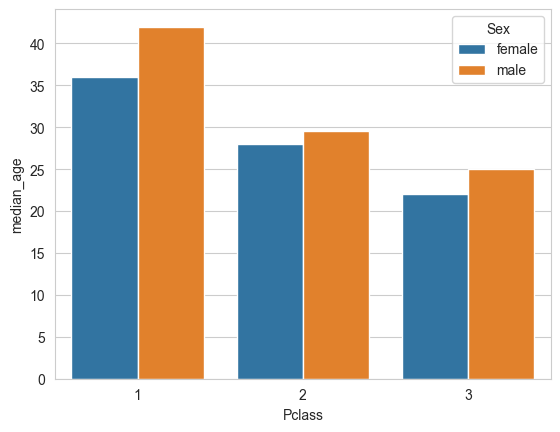

In [743]:
sns.barplot(data=age_class_sex, x='Pclass', y='median_age', hue='Sex')
plt.show()

先用Pclass和Sex对Age进行分组填充：

In [744]:
total['Age_Pclass'] = total.groupby(['Pclass','Sex'], dropna=False)['Age'].transform(lambda x: x.fillna(x.median()))

除此之外，在非数值型数据中，可以对Name进一步提取信息，Name的格式为:XXX, YY, ZZZ， 其中XXX是姓（Last Name），YY是Title，即对该乘客的称呼，ZZZ是名（First Name）。使用Title对Age进行分组填充是因为Title中包含着丰富的社会信息。

In [745]:
total['Title'] = total['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())
mapping = {'Mlle': 'Miss', 'Major': 'Mr', 'Col': 'Mr', 'Sir': 'Mr', 'Don': 'Mr', 'Mme': 'Miss', 'Jonkheer': 'Mr', 'Lady': 'Mrs', 'Capt': 'Mr', 'the Countess': 'Mrs', 'Ms': 'Miss', 'Dona': 'Mrs'}
total.replace({'Title':mapping}, inplace=True)
title_age = total.groupby(['Pclass','Title'])['Age'].median().reset_index(name='median_age')

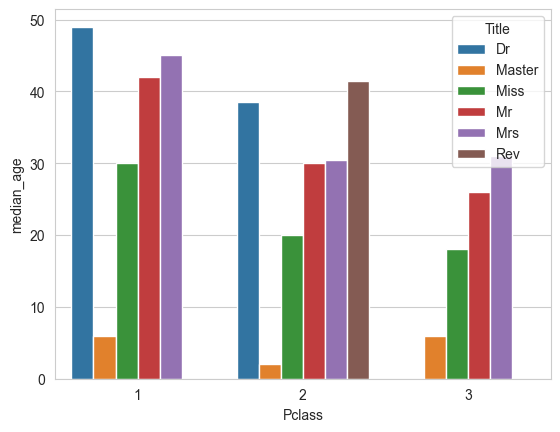

In [746]:
sns.barplot(data=title_age, x='Pclass',y='median_age', hue='Title')
plt.show()

- Dr称谓对应的年龄中位数大约在40岁到50岁之间，一等舱的Dr年纪偏大，二等舱的Dr年纪偏小。
- Master对应的乘客年龄最小，基本都是未成年男士
- Rev称谓对应的是牧师，其中位年龄也在40岁到50岁之间

In [747]:
total['Age_Title'] = total.groupby('Title', dropna=False)['Age'].transform(lambda x: x.fillna(x.median()))
total.drop('Title', axis=1, inplace=True)

#### Embarked 填充

起运港：key = S, C, Q

首先查看起运港的缺失值，Embarked这一列有两个缺失值，可以直接查看这两行，看看数据有什么共同点

In [748]:
total[total['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Pclass,Age_Title
61,62,1.0,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN,38.0,38.0
829,830,1.0,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN,62.0,62.0


这两条数据的共同点是：这两人都是女性，且都为一等舱乘客，她们的票价，舱号（B28）都是相同的。因此我们可以看看其他相同舱号的乘客大多从哪个起运港出发的。

In [749]:
b28 = total[(total['Cabin'].fillna('').str.startswith('B28'))]
b2 = total[(total['Cabin'].fillna('').str.startswith('B2'))]
print(f"多数B2舱的乘客的起运舱口:{b2['Embarked'].mode()}")
b2

多数B2舱的乘客的起运舱口:0    S
Name: Embarked, dtype: object


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Pclass,Age_Title
61,62,1.0,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.00,B28,NaN,38.0,38.0
540,541,1.0,1,"Crosby, Miss. Harriet R",female,36.0,0,2,WE/P 5735,71.00,B22,S,36.0,36.0
690,691,1.0,1,"Dick, Mr. Albert Adrian",male,31.0,1,0,17474,57.00,B20,S,31.0,31.0
745,746,0.0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.00,B22,S,70.0,70.0
781,782,1.0,1,"Dick, Mrs. Albert Adrian (Vera Gillespie)",female,17.0,1,0,17474,57.00,B20,S,17.0,17.0
829,830,1.0,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.00,B28,NaN,62.0,62.0
1196,1197,NaN,1,"Crosby, Mrs. Edward Gifford (Catherine Elizabeth Halstead)",female,64.0,1,1,112901,26.55,B26,S,64.0,64.0
1281,1282,NaN,1,"Payne, Mr. Vivian Ponsonby",male,23.0,0,0,12749,93.50,B24,S,23.0,23.0


查看B28舱号的其他游客时发现，B28舱号只有这两位缺失了Embarked游客。因此退一步，查看舱号开头为B2的乘客。
一共可以筛选出8条舱号开头为B2的乘客，除了缺失了Embarked值的两位游客，其他都是从S港口出发的，其中大部分也为女性。因此我们推测B28的两位乘客也是从S港口出发的。

In [750]:
total['Embarked'] = total['Embarked'].fillna('S')

#### Fare 填充

Fare数据只在测试集中有缺失，且缺失数量为1，可以直接查看缺失值的数据。

In [751]:
total[total['Fare'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_Pclass,Age_Title
1043,1044,NaN,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S,60.5,60.5


通过计算相关系数得到，票价与票务等级（Pclass）有强烈负相关，除此之外还与Sibsp和Parch有微弱的正相关。我们再假设票价与起运港也有一定关系。根据这几个特征，我们筛选出与该乘客相似的乘客所花的票钱，最后取中位数。

In [752]:
total.corrwith(total['Fare'], numeric_only=True, method='spearman')

PassengerId   -0.003583
Survived       0.323736
Pclass        -0.709019
Age            0.192676
SibSp          0.445566
Parch          0.400301
Fare           1.000000
Age_Pclass     0.218694
Age_Title      0.172687
dtype: float64

In [753]:
total.groupby(['Embarked'])['Fare'].median()

Embarked
C    28.51875
Q     7.75000
S    13.00000
Name: Fare, dtype: float64

In [754]:
cabin_fare = total[(total['Pclass']==3)&(total['Embarked']=='S')&(total['SibSp']==0)&(total['Parch']==0)]
print(f"票价中位数为:{cabin_fare['Fare'].median()}")

票价中位数为:7.8958


In [755]:
# 对缺失值进行填充
total['Fare'] = total['Fare'].fillna(cabin_fare['Fare'].median())

#### Cabin

Cabin是客舱号，在数据集中Cabin的缺失值较多。缺失的Cabin数量大约有总数据的77.46%。一般如此多的缺失数量我会想忽略这个特征，但是Cabin的第一个字母是指客舱所在的甲板位置，不同的区域可能存活率也不同
![alt text](https://vignette.wikia.nocookie.net/titanic/images/f/f9/Titanic_side_plan.png/revision/latest?cb=20180322183733)

客舱号所在的甲板根据乘客的等级进行分割，假设将缺失值全部填充为M

In [756]:
cabin_null_values = total['Cabin'].isnull().sum()
print(f"Cabin的缺失值数量:{cabin_null_values}")

null_ratio = round(100*cabin_null_values/len(total),2)
print(f"占比:{null_ratio}%")

Cabin的缺失值数量:1014
占比:77.46%


- A和B以及C甲板只有一等舱的乘客
- D甲板有一等舱和二等舱的乘客
- E甲板有所有等级的乘客
- F甲板有二等舱和三等舱的乘客
- G甲板只有三等舱的乘客
- 除此之外T甲板只有一个乘客，且是一等舱的

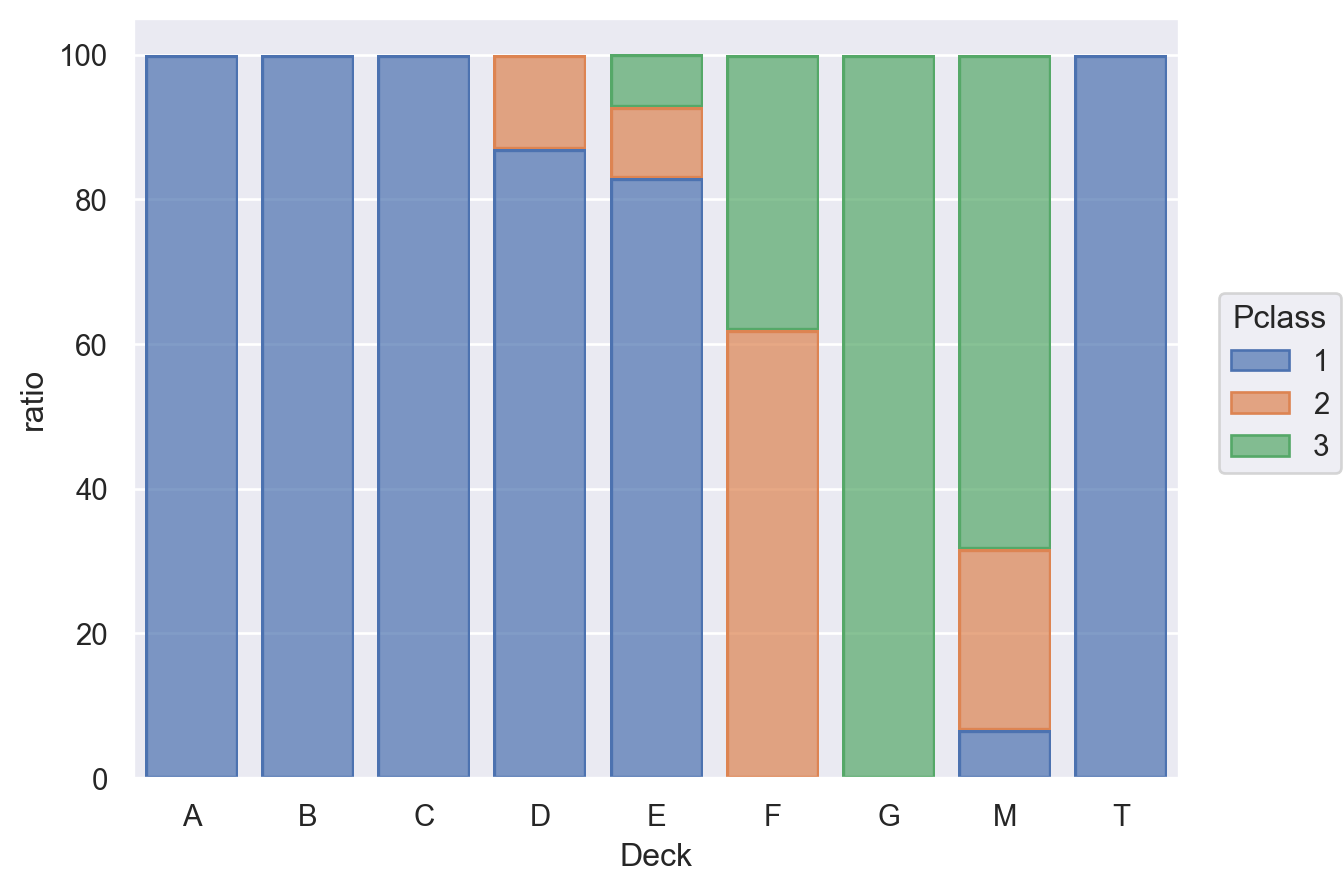

In [757]:
total['Deck'] = total['Cabin'].apply(lambda x: 'M' if pd.isna(x) else x[0])

pclass_cabin = total.groupby(['Deck','Pclass'])['PassengerId'].count().reset_index(name='count')
pclass_cabin['total'] = pclass_cabin.groupby('Deck')['count'].transform('sum')
pclass_cabin['ratio'] = round(100*pclass_cabin['count']/pclass_cabin['total'],2)
pclass_cabin['Pclass'] = pclass_cabin['Pclass'].astype('category')
so.Plot(pclass_cabin, x="Deck",y='ratio', color="Pclass").add(so.Bar(), so.Stack())

- 其中A, B, C有100%的一等舱乘客
- D甲板中有86.96%的一等舱乘客和13.04%的二等舱乘客
- E甲板中有83%的一等舱乘客和9.76%的二等舱乘客以及7.32%的三等舱乘客。
- F甲板中有62%的二等舱乘客和38%的三等舱乘客。
- G甲板有100%的三等舱乘客

计算生存率和甲板位置的相关关系, 可以得到类似于协方差矩阵的皮尔逊关系系数矩阵。得到甲板位置与Survived之间有微弱负相关的线性关系。但这不能代表两者之间没有关系，因为两者之间可能是非线性的关系。进一步可以对甲板进行分组，计算每一组的生存率。由于T甲板处只有一个值，且其属于Pclass1，可以将其移到甲板A。

In [758]:
total.loc[total[total['Deck']=='T'].index,'Deck']='A'
y = pd.concat([train[['PassengerId','Survived']], truth]).reset_index(drop=True)
codes = np.arange(9)
categories = sorted(total['Deck'].unique())
mapping = dict(zip(categories, codes))
deck_code = total['Deck'].apply(lambda x: mapping[x])
corrcoef = deck_code.corr(y['Survived'])
print(f"皮尔逊相关系数为:{corrcoef:.3f}")

皮尔逊相关系数为:-0.279


观察可得，在Pclass1人数占比较多的甲板上，生存率较高——如B、C、D、E，而M甲板由于二等舱和三等舱的乘客较多，其生存比例较低。根据客舱等级，将甲板进行分组：
- A、B、C都是Pclass 1的人，因此分为一组。
- D、E服务于各类舱级，因此分为一组
- F、G没有一等舱乘客，因此分为一组

<Axes: xlabel='Deck', ylabel='survived'>

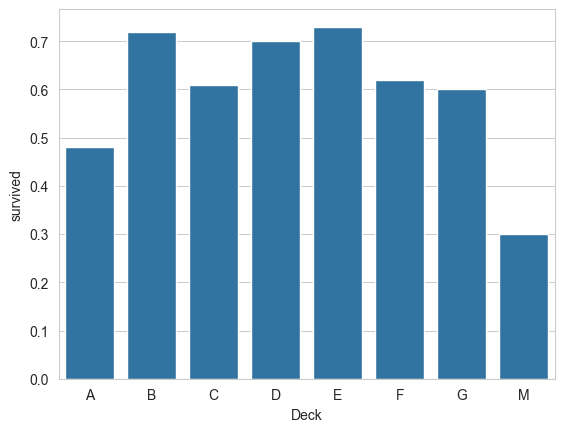

In [759]:
survived = pd.merge(total[['PassengerId','Deck']], y, on='PassengerId').groupby('Deck')['Survived'].mean().round(2).reset_index(name='survived')

sns.barplot(x='Deck', y='survived', data=survived)

In [760]:
total.replace({'Deck':['A','B','C']}, 'ABC', inplace=True)
total.replace({'Deck':['D','E']}, 'DE', inplace=True)
total.replace({'Deck':['F','G']}, 'FG', inplace=True)

In [761]:
total['Deck'].value_counts()

Deck
M      1014
ABC     182
DE       87
FG       26
Name: count, dtype: int64

### 探索数据分布（Exploratory Data Distribution）

探索数据集中数据的分布，以及训练集中不同特征与生存与否的分布

#### 目标值分布

在训练集上查看目标值的分布：

- 其中生存人数占比38.38% —— **Class 1**
- 没有活下来的人数占比61.62%。—— **Class 0**

Text(0, 0.5, 'Passenger count')

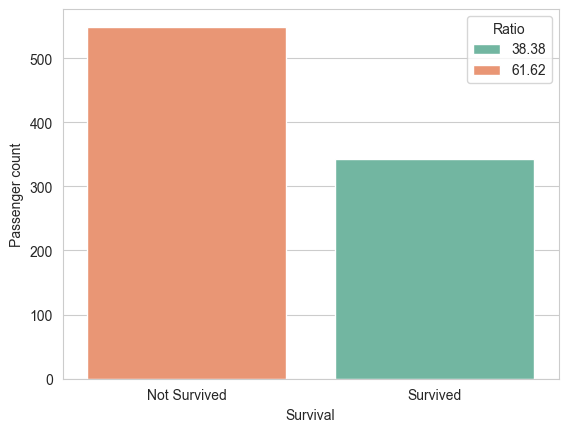

In [762]:
target = train['Survived'].value_counts().reset_index(name='count')
target['Ratio'] = round(100*target['count']/target['count'].sum(),2)

fig, ax = plt.subplots()
sns.barplot(data=target, x='Survived', y='count',hue='Ratio',palette='Set2', ax=ax)
ax.set_xticks(range(len(target['Survived'])))
ax.set_xticklabels(['Not Survived', 'Survived'])
ax.set_xlabel('Survival')
ax.set_ylabel('Passenger count')

#### 数值型数据分布

- 连续型数据有：Age, Fare
- 离散型数据有：Sibsp, Parch
- 分类数据：Sex, Pclass, Embarked, Deck

首先查看Age和Fare相对于Survived的数据分布，根据分布可以看出：
- 遇难者的年龄分布的峰度比幸存者的年龄分布要大得多，集中于20到40岁之间，其中30岁左右的人尤其多。20岁以下的人更容易幸存。
- 遇难者的票价分布比幸存者票价分布更加偏斜，集中于低票价区，而高票价区（100左右）的幸存人数更多。从之前的分析中我们也得知，低票价乘客集中于二三等舱，其位置也影响生存概率。

Age中幸存者的年龄分布的峰度:0.23724315667233808
Age中遇难者的年龄分布的峰度:0.9432812651040385


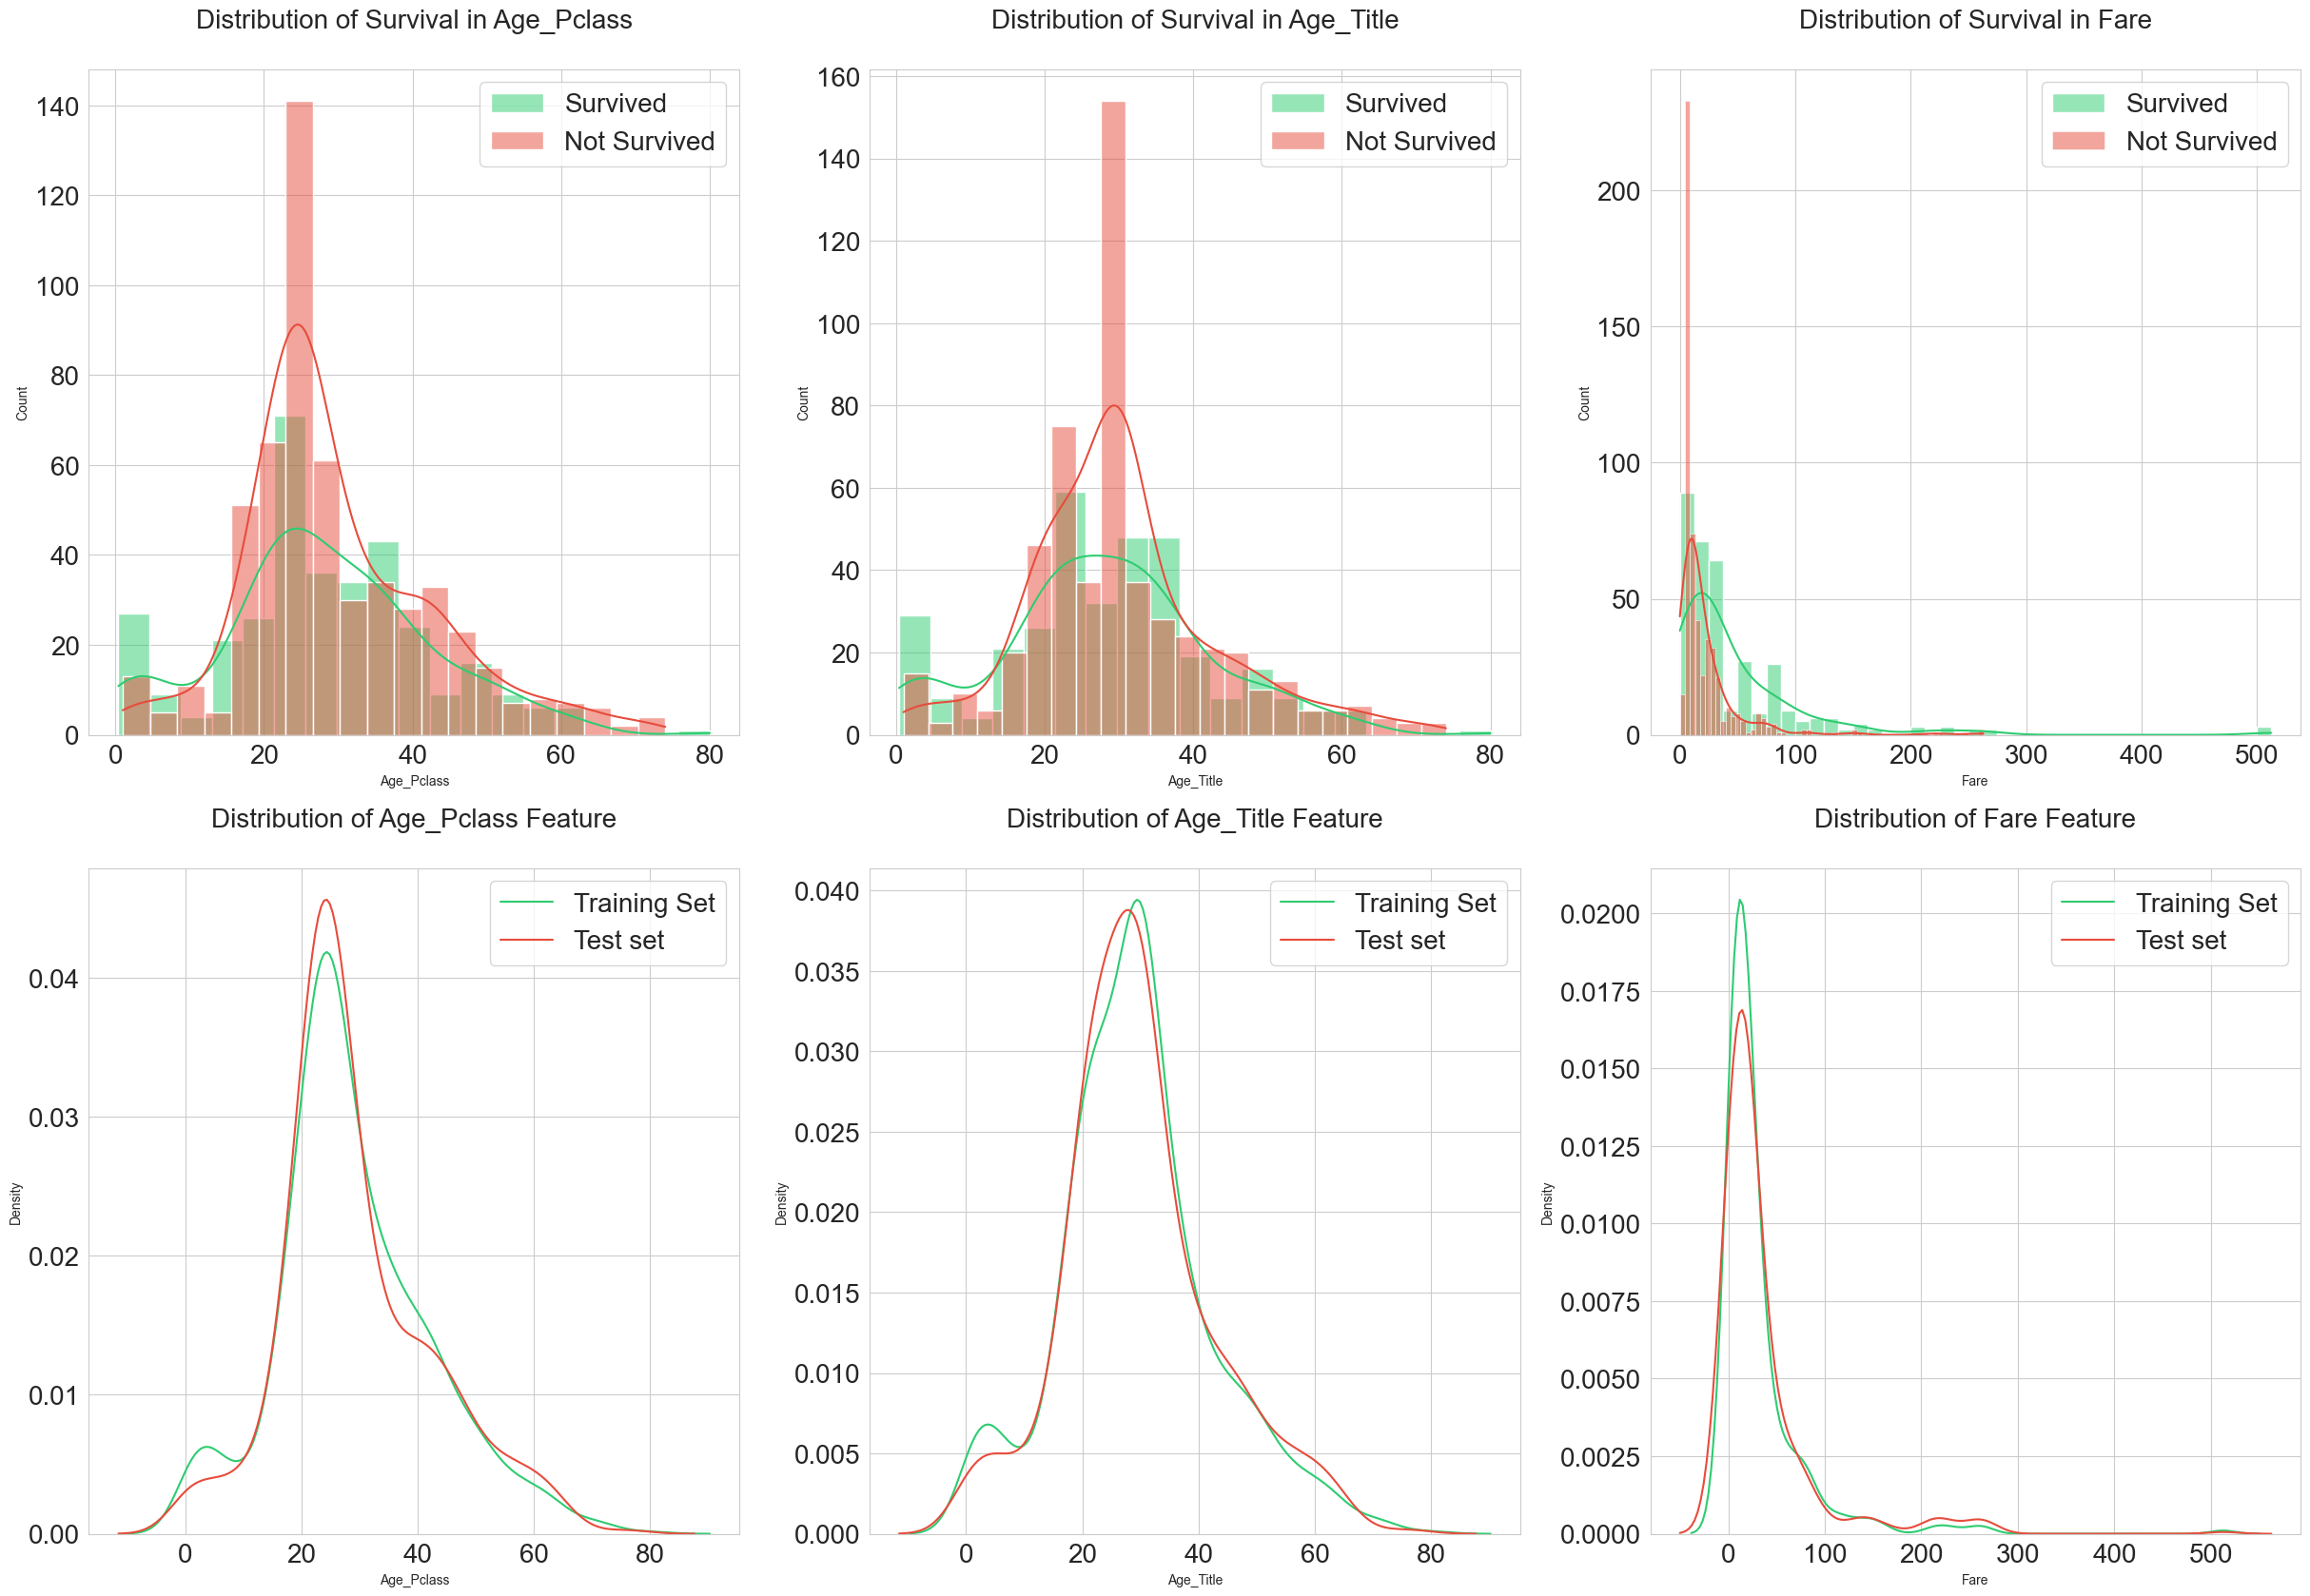

In [763]:
af_train = total[total['PassengerId']<=891][['PassengerId','Age_Pclass','Age_Title','Fare','Survived']]
af_test = total[total['PassengerId']>891][['PassengerId','Age_Pclass','Age_Title','Fare','Survived']]

age_survived_kurt = af_train[af_train['Survived']==1]['Age_Pclass'].kurtosis()
age_notsurvived_kurt = af_train[af_train['Survived']==0]['Age_Pclass'].kurtosis()

print(f"Age中幸存者的年龄分布的峰度:{age_survived_kurt}")
print(f"Age中遇难者的年龄分布的峰度:{age_notsurvived_kurt}")

fig, ax = plt.subplots(ncols=3, nrows=2, figsize=(30,20))

flag = af_train['Survived']==1

for i, feature in enumerate(['Age_Pclass', 'Age_Title' ,'Fare']):
    sns.histplot(af_train[flag][feature], kde=True, label='Survived', color='#2ecc71', ax=ax[0][i])
    sns.histplot(af_train[~flag][feature], kde=True, label='Not Survived', color='#e74c3c', ax=ax[0][i])

    sns.kdeplot(af_train[feature], label='Training Set', color='#2ecc71', ax=ax[1][i])
    sns.kdeplot(af_test[feature],  label='Test set', color='#e74c3c', ax=ax[1][i])

    for j in range(2):
        ax[j][i].tick_params(axis='x', labelsize=20)
        ax[j][i].tick_params(axis='y', labelsize=20)

    ax[0][i].legend(loc='upper right', prop={'size': 20})
    ax[1][i].legend(loc='upper right', prop={'size': 20})

    ax[0][i].set_title('Distribution of Survival in {}'.format(feature), size=20, y=1.05)

    ax[1][0].set_title('Distribution of {} Feature'.format('Age_Pclass'), size=20, y=1.05)
    ax[1][1].set_title('Distribution of {} Feature'.format('Age_Title'), size=20, y=1.05)
    ax[1][2].set_title('Distribution of {} Feature'.format('Fare'), size=20, y=1.05)

#### 类别数据分布

类别数据有：Sex, Embarked, Deck, Pclass

除此之外，离散数据的Parch和Sibsp离散值如果较小，也可作为类别数据一起处理。

In [764]:
print(f"Parch所包含的离散数值:{total['Parch'].unique()}")
print(f"Sibsp所包含的离散数值:{total['SibSp'].unique()}")

Parch所包含的离散数值:[0 1 2 5 3 4 6 9]
Sibsp所包含的离散数值:[1 0 3 4 2 5 8]


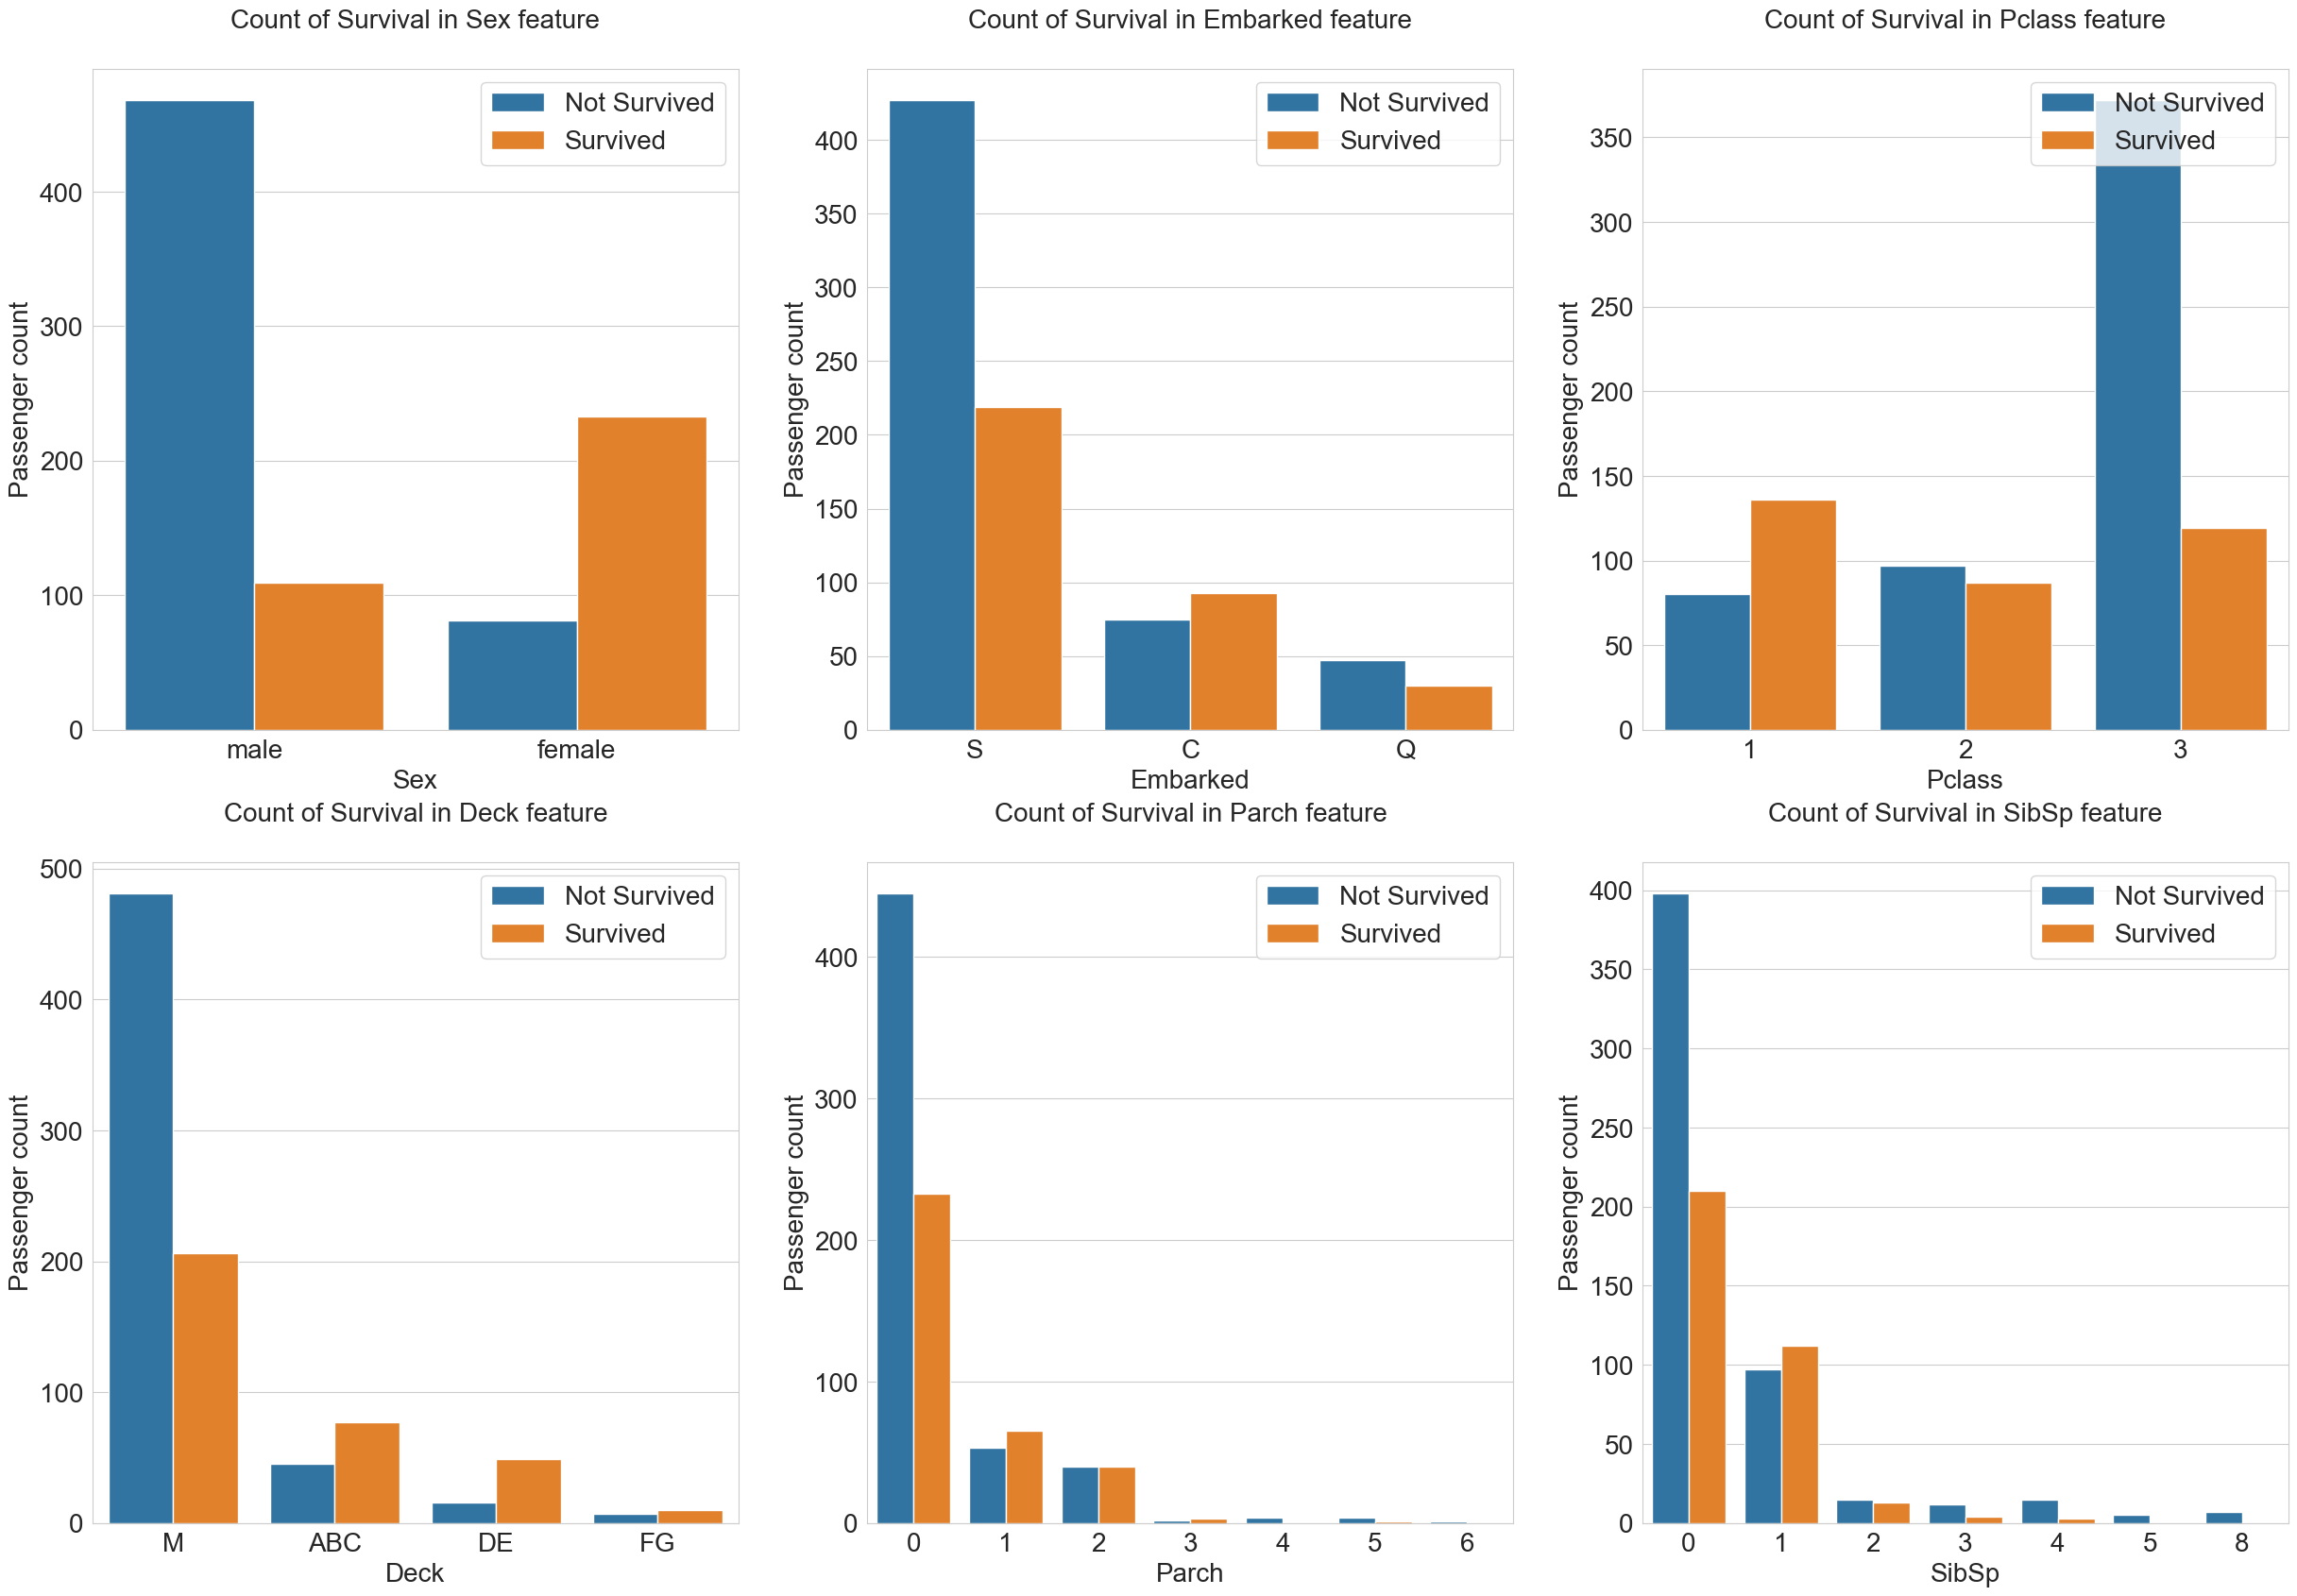

In [765]:
cate = total[total['PassengerId']<=891][['PassengerId','Sex','Embarked','Pclass','Deck','Parch','SibSp','Survived']]

features = ['Sex','Embarked','Pclass','Deck','Parch','SibSp']
flag = cate['Survived']==1

fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(30,20))

for i, feature in enumerate(features):
    plt.subplot(2,3,i+1)
    sns.countplot(data=cate, x=feature, hue='Survived')

    plt.tick_params(axis='x', labelsize=20)
    plt.tick_params(axis='y', labelsize=20)

    plt.xlabel("{}".format(feature), size=20)
    plt.ylabel("Passenger count", size=20)

    plt.legend(['Not Survived','Survived'], loc='upper right', prop={'size': 20})
    plt.title("Count of Survival in {} feature".format(feature), size=20, y=1.05)

- 女性生存比例相比男性更高
- 从S港口乘船的人最多，但是从C港口乘船的人的幸存率更高。
- 头等舱的乘客幸存率更高。
- 船上大多数人没有同行的亲人，有同行家人的人中，有一个兄弟姐妹/父母/孩子/配偶的人的幸存比率更高。

#### 相关性

筛选出相关性系数>0.1的特征，将特征组合按照相关性的绝对值从大到小排列，忽略正负关系。

- 除了两种用不同方式填充的Age列之外，Fare和Pclass的相关性最强烈，推测舱位等级越高，票价越高

In [766]:
corrs = total.corr(numeric_only=True).abs().unstack().reset_index(name='Corr').rename(columns={'level_0':'Feature1','level_1':'Feature2'})
corrs.sort_values(by='Corr', ascending=False, inplace=True)
corrs = corrs[(corrs['Corr']!=1)&(corrs['Corr']>0.1)].reset_index(drop=True)
corrs.drop(index=corrs.iloc[1::2,:].index, inplace=True)
corrs = corrs.reset_index(drop=True)
corrs

,Feature1,Feature2,Corr
0,Age_Title,Age_Pclass,0.968805
1,Fare,Pclass,0.558742
2,Pclass,Age_Pclass,0.451983
3,Pclass,Age,0.408106
4,Age_Title,Pclass,0.388031
5,Parch,SibSp,0.373587
6,Survived,Pclass,0.338481
7,Survived,Fare,0.257307
8,SibSp,Age,0.243699
9,Fare,Parch,0.221668


Text(0.5, 1.05, 'Test Set Correlation Matrix')

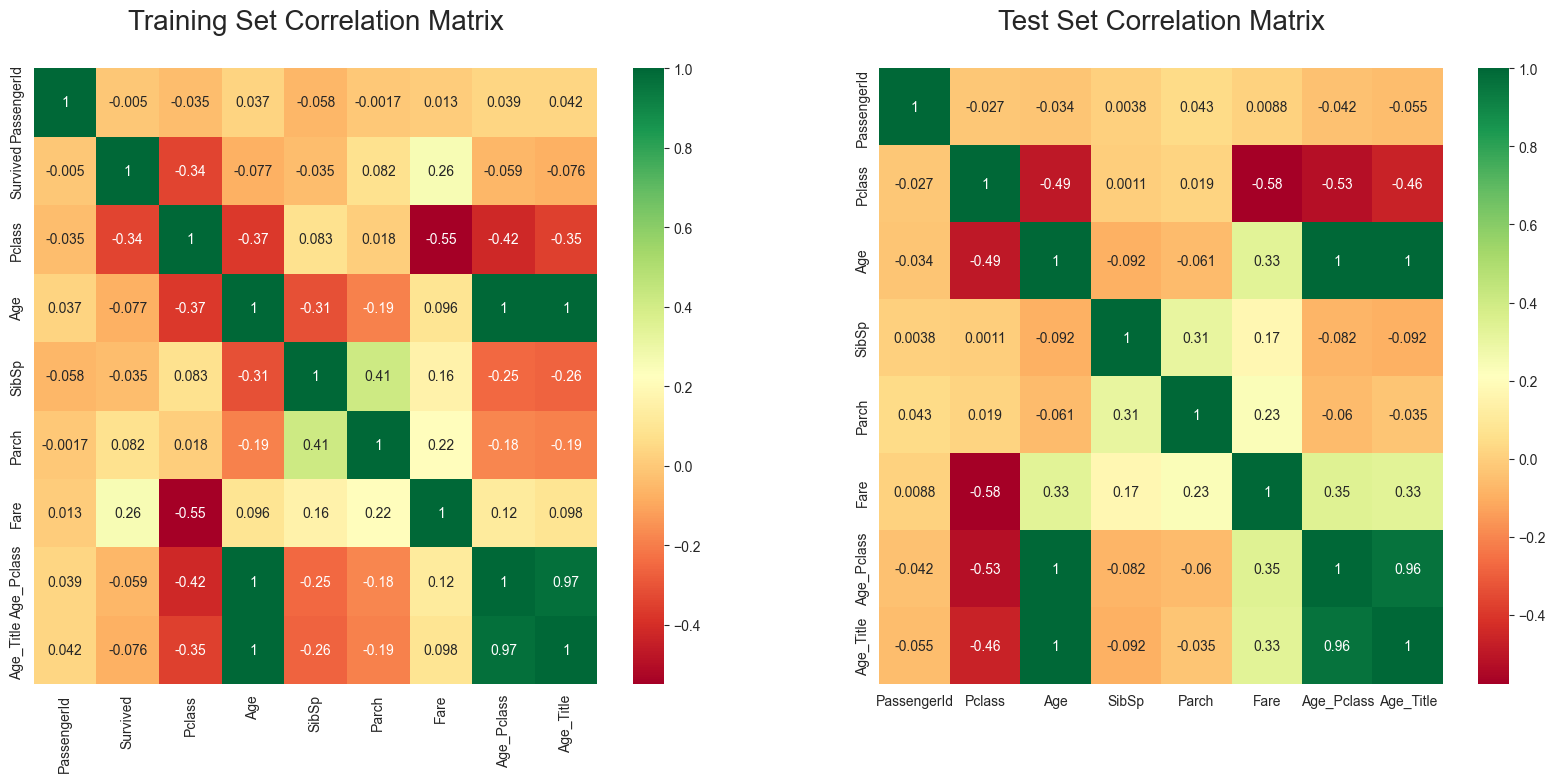

In [767]:
train = total[total['PassengerId']<=891]
test = total[total['PassengerId']>891].drop('Survived', axis=1)

corr_train = train.corr(numeric_only=True)
corr_test = test.corr(numeric_only=True)

fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(20,8))

sns.heatmap(corr_train, annot=True, cmap='RdYlGn', ax=axs[0])
sns.heatmap(corr_test, annot=True, cmap='RdYlGn', ax=axs[1])

axs[0].set_title('Training Set Correlation Matrix', size=20, y=1.05)
axs[1].set_title('Test Set Correlation Matrix', size=20, y=1.05)

## 特征工程（Feature Engineering）

### 连续型数据分箱

#### Age

在探索性数据分析中得到，Age数据较为集中在20岁到40岁之间，但是最小的年龄不满周岁，最大年龄达到80岁左右，因此可以对年龄数据进行分箱，分组查看其与生存率的关系。分箱是利用等规模分箱法。因为年龄分布不均，使用等组距分箱法会导致大多数数据集中在20岁到40岁组，无法有效分析。通过对Age_Pclass分箱捕捉到，第一组中0到16岁中生存率最高，22岁到25岁生存率最低。

Text(0.5, 1.0, 'Survival Counts in Age Feature')

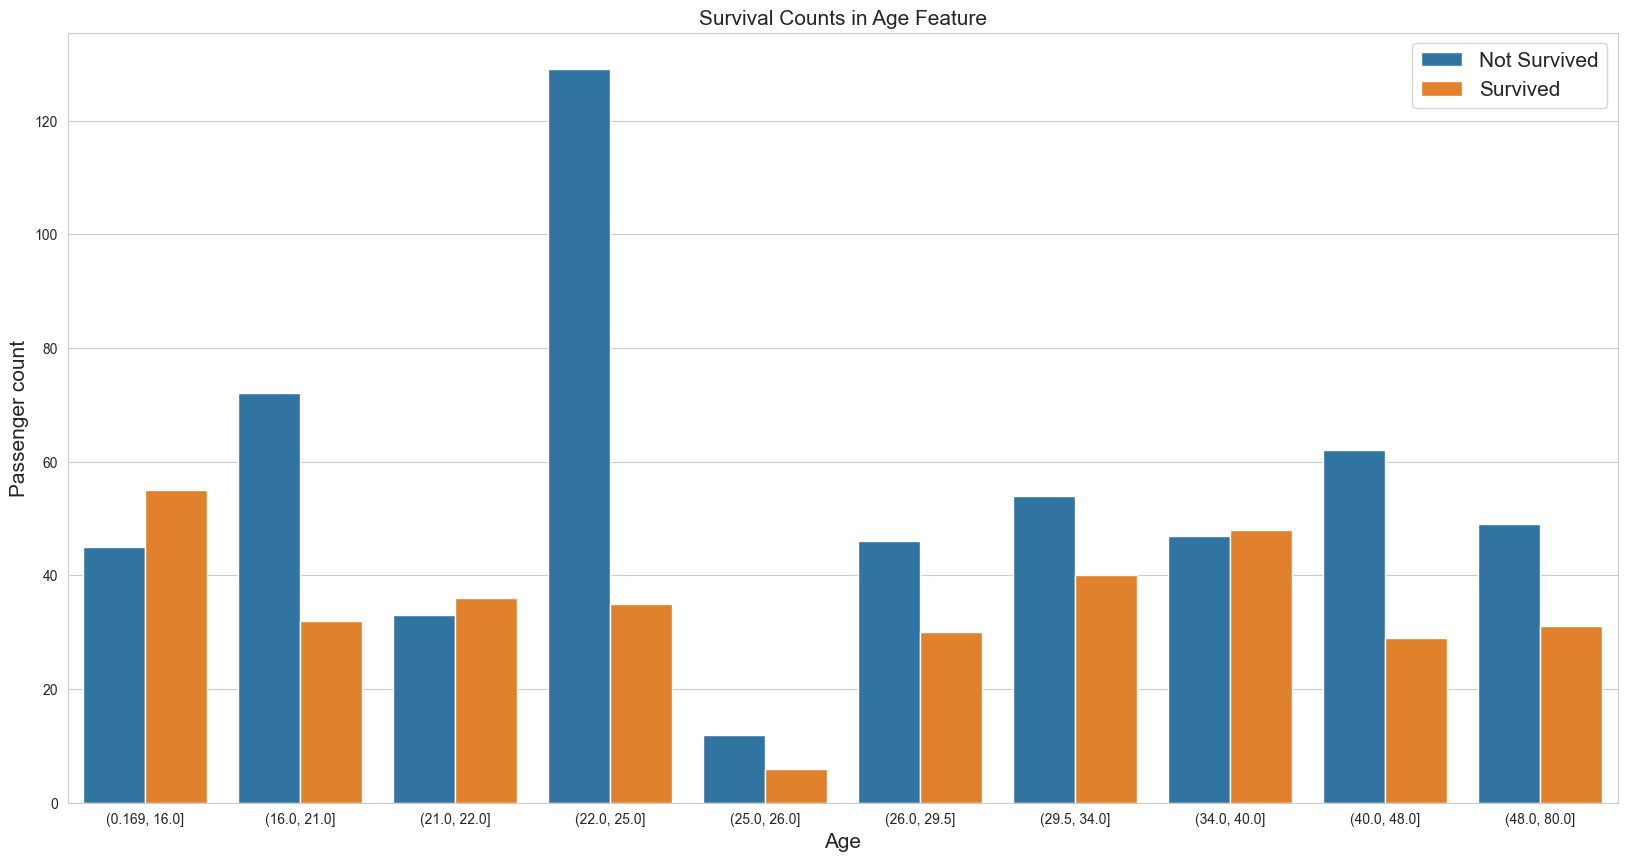

In [768]:
total['Age_group'] = pd.qcut(total['Age_Pclass'], q=10)

age_group = total[['PassengerId','Age_group','Survived']]

plt.figure(figsize=(20,10))
sns.countplot(x='Age_group', hue='Survived', data=age_group)

plt.xlabel("Age", size=15)
plt.ylabel("Passenger count", size=15)

plt.legend(['Not Survived','Survived'], loc='upper right', prop={'size': 15})
plt.title('Survival Counts in Age Feature', size=15)

将Age_Title分为4组进行分箱，随着年龄的增长，存活人数减少，但是存活比例在30~36年龄段达到顶峰，22岁到30岁之间的遇难人数比例最高。

Text(0.5, 1.0, 'Survival Counts in Age Feature')

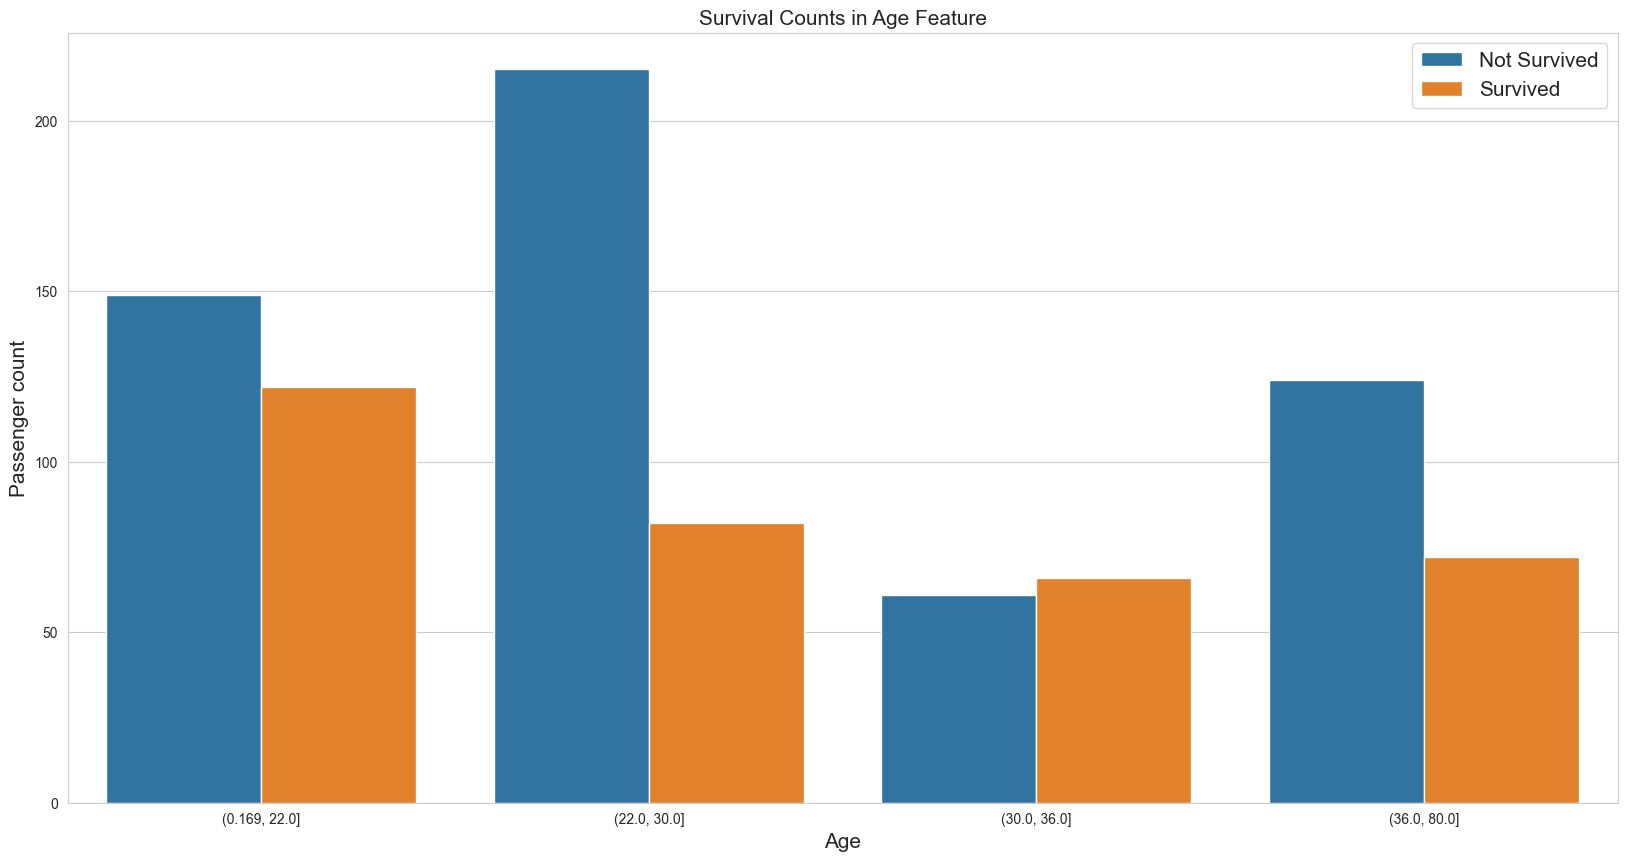

In [769]:
total['AgeBin'] = pd.qcut(total['Age_Title'], 4)

age_bin = total[['PassengerId','AgeBin','Survived']]

plt.figure(figsize=(20,10))
sns.countplot(x='AgeBin', hue='Survived', data=age_bin)

plt.xlabel("Age", size=15)
plt.ylabel("Passenger count", size=15)

plt.legend(['Not Survived','Survived'], loc='upper right', prop={'size': 15})
plt.title('Survival Counts in Age Feature', size=15)

#### Fare

对票价同样进行等规模分箱，在探索型分析中我们得到，Fare是极度偏斜的，其中Not Survived数据比Survived数据更加偏斜。由箱线图可得，幸存者的中位数票价要比遇难者高，偏度也没有遇难者票价分布大。

[Text(0, 0, 'Not Survived'), Text(1, 0, 'Survived')]

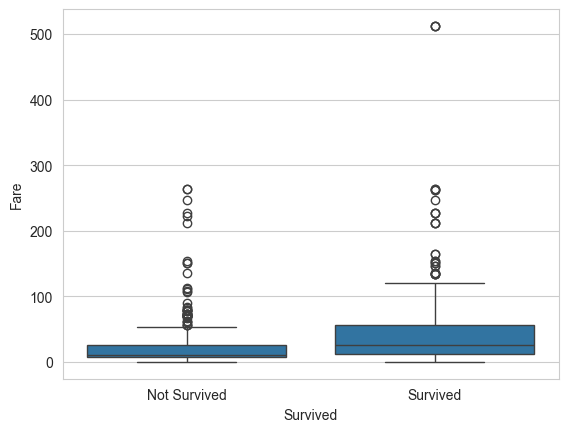

In [770]:
fare = total[['PassengerId','Fare','Survived']]
ax = sns.boxplot(data=fare, x='Survived', y='Fare')
ax.set_xticks(range(2))
ax.set_xticklabels(['Not Survived', 'Survived'])

将Fare进行等规模分箱，创建两个新特征，分别将Fare分为13组和5组，用于不同的模型训练。

分为13组时，随着票价的升高，幸存者比率也越来越高，遇难者的比率相对降低。到票价最高档的时候，幸存者比率已经远超过遇难者。一个不太一样的组是(26.82, 41.579]这组，在此组中，遇难者比例仍然较高。

Text(0.5, 1.0, 'Survival Counts in Fare Feature')

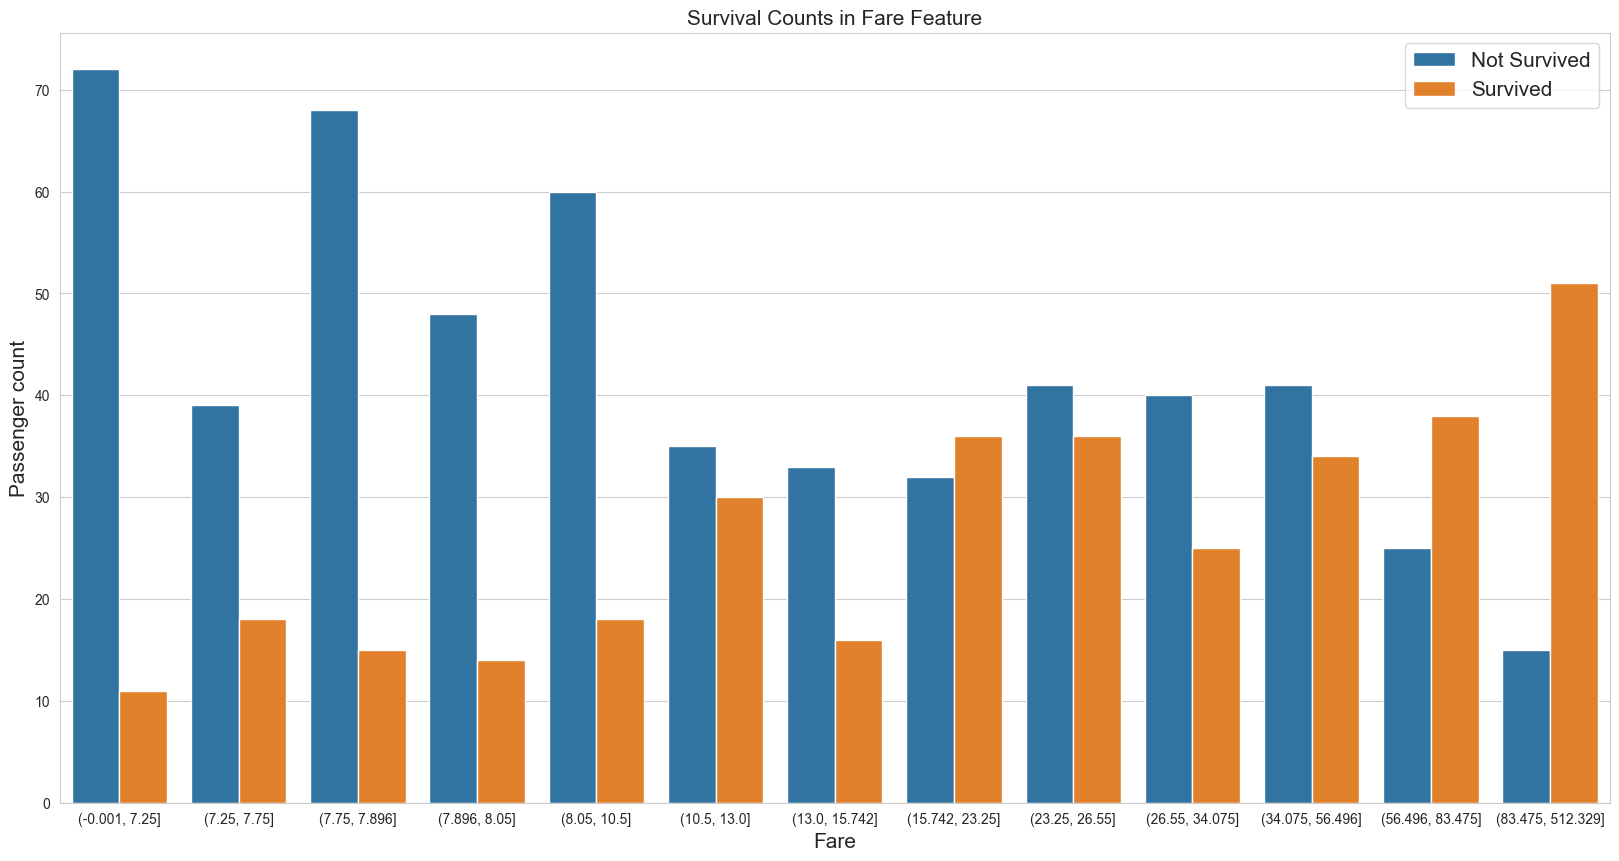

In [771]:
total['Fare_group'] = pd.qcut(total['Fare'], q=13)
fare_group = total[['PassengerId','Fare_group','Survived']]


plt.figure(figsize=(20,10))
sns.countplot(data=fare_group, x='Fare_group', hue='Survived')

plt.xlabel("Fare", size=15)
plt.ylabel("Passenger count", size=15)

plt.legend(['Not Survived','Survived'], loc='upper right', prop={'size': 15})
plt.title("Survival Counts in Fare Feature", size=15)

同理，将Fare分为5组，观察大趋势可以发现，随着票价区段的升高，乘客幸存的比例也在增高

Text(0.5, 1.0, 'Survival Counts in Fare Feature')

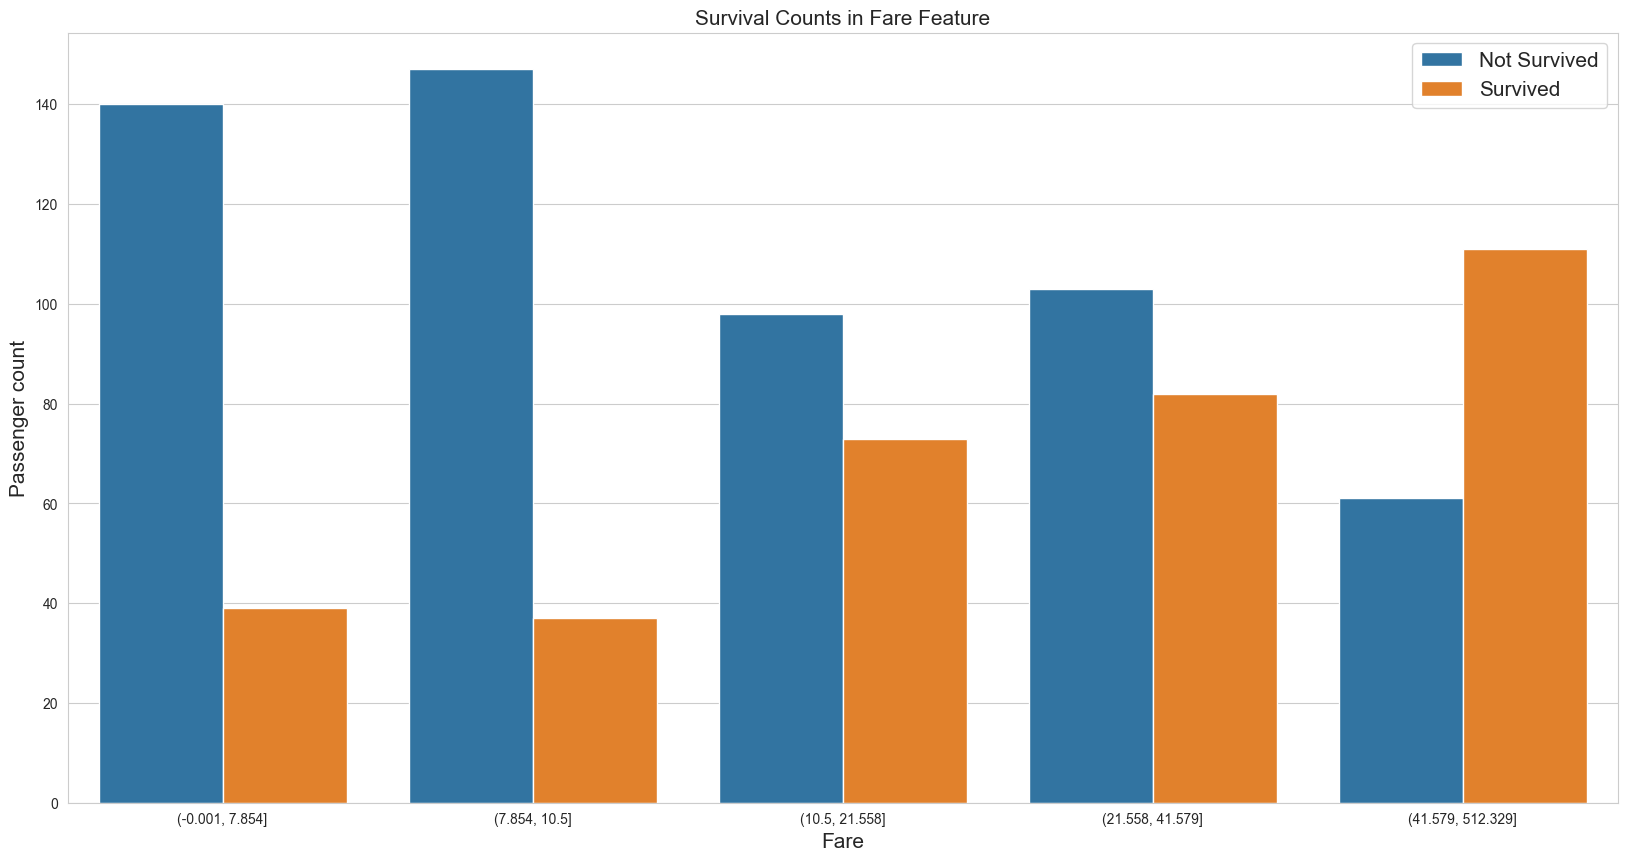

In [772]:
total['FareBin'] = pd.qcut(total['Fare'], q=5)
fareBin = total[['PassengerId','FareBin','Survived']]

plt.figure(figsize=(20,10))
sns.countplot(data=fareBin, x='FareBin', hue='Survived')

plt.xlabel("Fare", size=15)
plt.ylabel("Passenger count", size=15)

plt.legend(['Not Survived','Survived'], loc='upper right', prop={'size': 15})
plt.title("Survival Counts in Fare Feature", size=15)

### 频率编码（Frequency Encoding）

#### Family Size

计算Family Size: Family Size = Parch+SibSp+1

- Family Size = 1, 标记为Alone - 说明是独自来的
- Family Size = 2, 3, 4, 标记为Small - 说明家庭规模较小
- Family Size = 5, 6 标记为Medium
- Family Size >=7 标记为 Large

分组后，家庭成员数目较小的组幸存率更高

<Axes: xlabel='FamilySize', ylabel='count'>

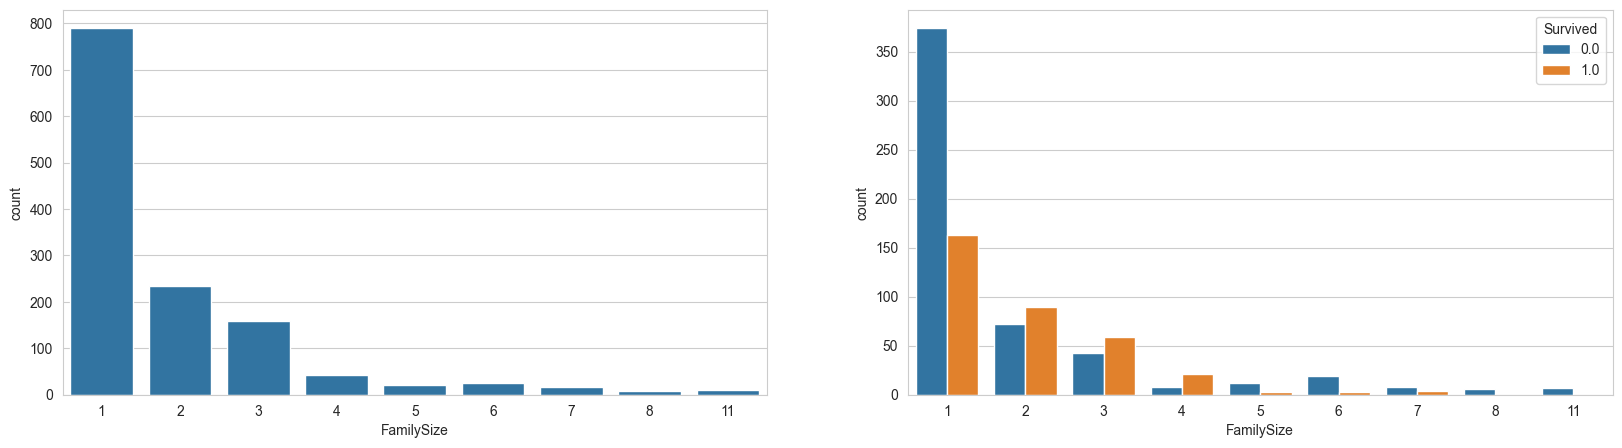

In [773]:
total['FamilySize'] = total['Parch'] + total['SibSp'] + 1

familysize = total['FamilySize'].value_counts().reset_index(name='count')
famliy = total[['PassengerId','FamilySize','Survived']]

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(20,5))
sns.barplot(data=familysize, x='FamilySize', y='count', ax=ax[0])
sns.countplot(data=famliy, x='FamilySize', hue='Survived',ax=ax[1])

<Axes: xlabel='FamilySizeGroup', ylabel='count'>

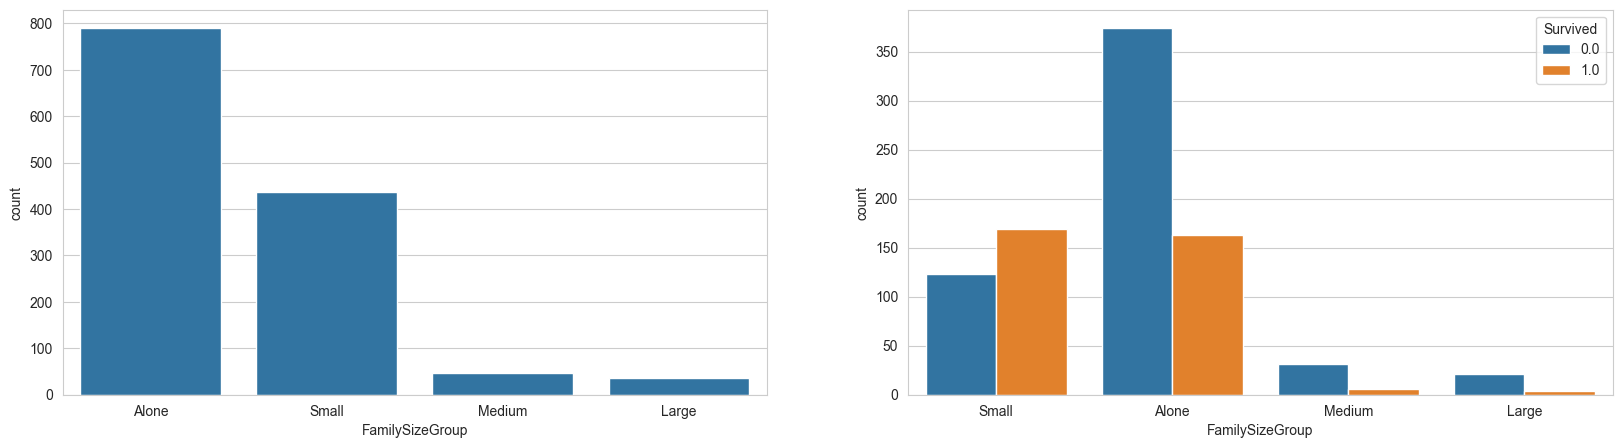

In [774]:
mapping = {1:'Alone', 2:'Small', 3:'Small', 4:'Small', 5:'Medium', 6:'Medium', 7:'Large', 8:'Large', 11:'Large'}
total['FamilySizeGroup'] = total['FamilySize'].map(mapping)
familygroup = total['FamilySizeGroup'].value_counts().reset_index(name='count')
familygrouped = total[['PassengerId','FamilySizeGroup','Survived']]

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(20,5))
sns.barplot(data=familygroup, x='FamilySizeGroup', y='count', ax=ax[0])
sns.countplot(data=familygrouped, x='FamilySizeGroup', hue='Survived',ax=ax[1])

#### Ticket Frequency

Ticket并不是唯一值，其中有很多重复值， 这是因为有很多人购买的团票，这些人可能是一家人，也可能是和朋友一起前来，这些人的车票号码是一样的。我们可以根据车票号码判断哪些人是一起的。通过计算Ticket出现的频率将Ticket进行分组。再对Ticket出现的频率进行分组，就像Family Size一样，计算同行人数量。

Text(0.5, 1.05, 'Count of Survival in Ticket Frequency Feature')

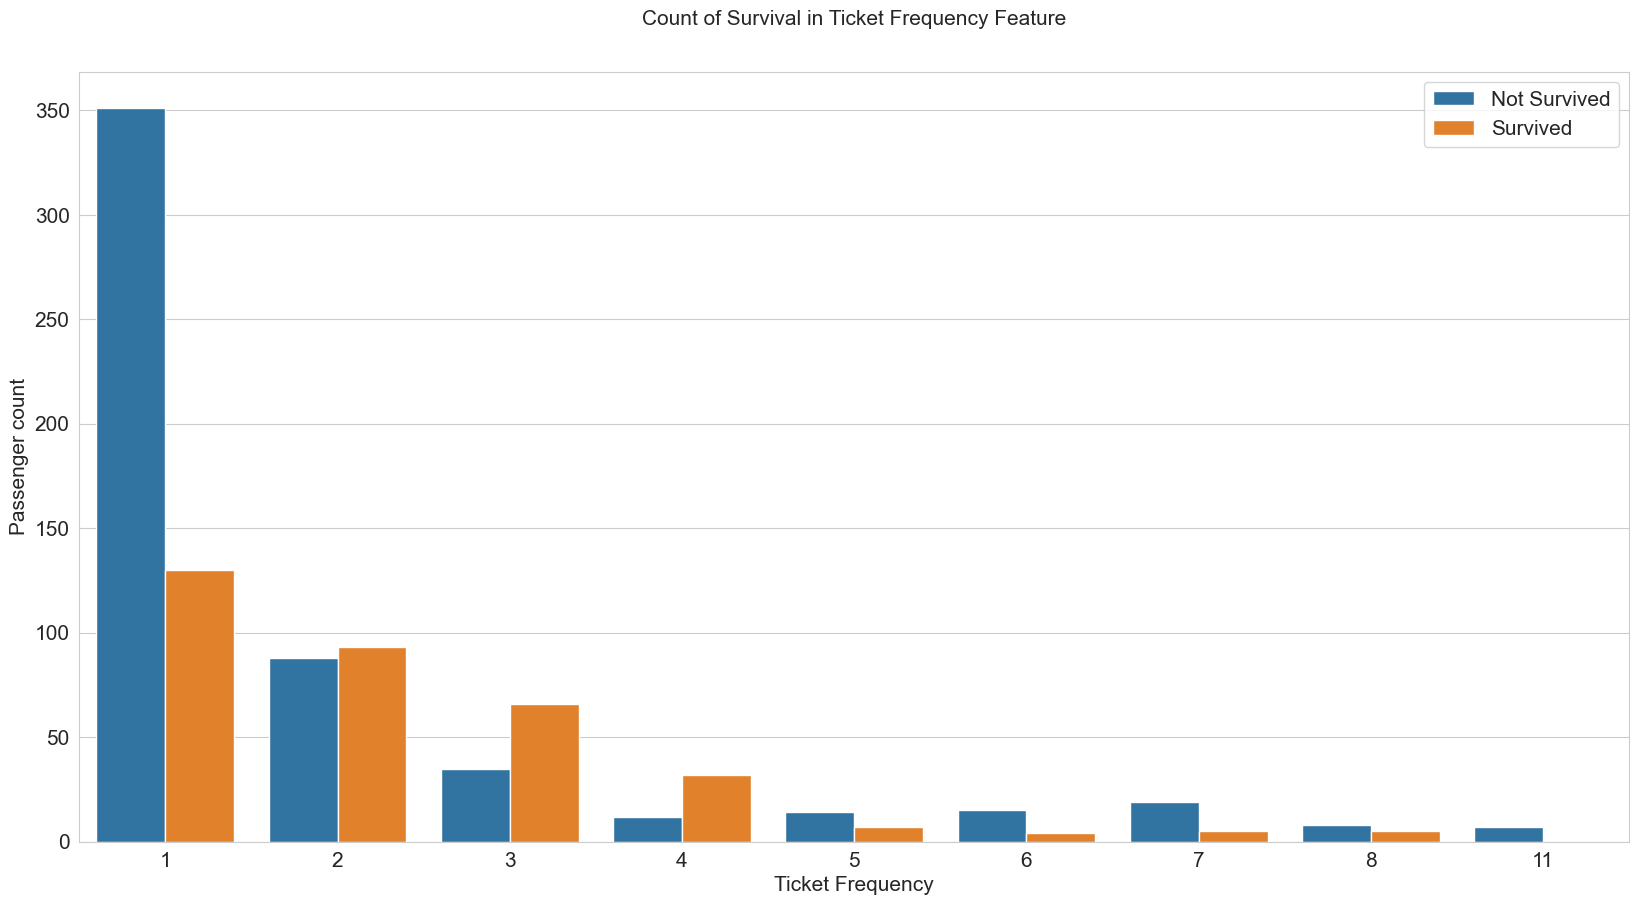

In [775]:
total['Ticket'] = total['Ticket'].astype(str).str.strip()
total['TicketFreq'] = total.groupby('Ticket')['Ticket'].transform('count')

ticket_fre = total[['PassengerId','TicketFreq','Survived']]

plt.figure(figsize=(20,10))
sns.countplot(data=ticket_fre, x='TicketFreq', hue='Survived')
plt.xlabel('Ticket Frequency', size=15)
plt.ylabel('Passenger count', size=15)

plt.legend(['Not Survived','Survived'], prop={'size': 15})

plt.tick_params(axis='x', labelsize=15)
plt.tick_params(axis='y', labelsize=15)

plt.title('Count of Survival in Ticket Frequency Feature', size=15, y=1.05)

### 处理Name - Title

Name的格式常常为XXX, title. ZZZ格式，其中title是一个人的头衔，通常有相应的含义，可以提取出来作为特征，在前面，使用过Title对Age进行分组，这里对Title进行进一步处理


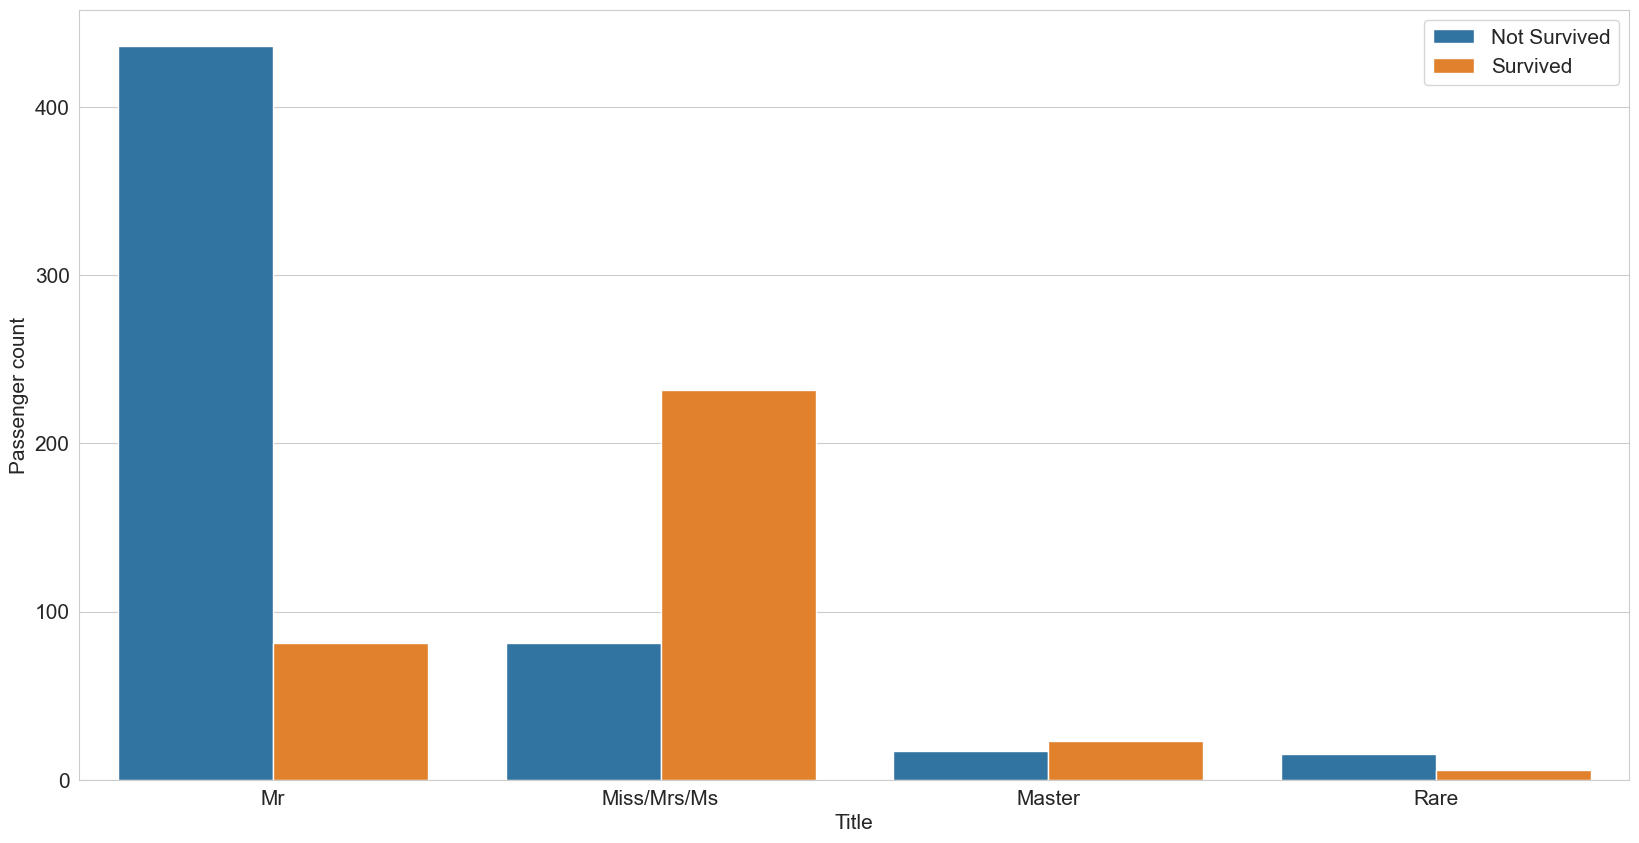

In [776]:
total['Title'] = total['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())

total['Title'] = total['Title'].replace(['Dona','Mme','Mlle','Ms','Mrs','Miss','Lady','the Countess'], 'Miss/Mrs/Ms')
total['Title'] = total['Title'].replace(['Dr', 'Col', 'Major', 'Jonkheer', 'Capt', 'Sir', 'Don', 'Rev'],'Rare')

title_group = total[['PassengerId','Title','Survived']]

plt.figure(figsize=(20,10))
sns.countplot(data=title_group, x='Title', hue='Survived')

plt.xlabel("Title", size=15)
plt.ylabel("Passenger count", size=15)

plt.legend(['Not Survived','Survived'], loc='upper right', prop={'size': 15})

plt.tick_params(axis='x', labelsize=15)
plt.tick_params(axis='y', labelsize=15)

### Family Survival Rate

构建新特征Family Survival: 目的是利用“**同姓 + 同票价**”这一线索，推测每个乘客的家庭成员或团体生存信息。

为什么要这么做？
因为：
- 泰坦尼克号上很多人是家庭或朋友一起登船的；
- 如果家人中有人生还或遇难，往往能反映该群体的生存概率；
- 这个群体特征可以强烈补充个体特征（如性别、舱位、年龄）之外的信息。

所有乘客初始设为 0.5，代表“未知”；若稍后确定他所在家庭中有人生还或遇难，则更新为 1 或 0。

✅ 1 → 家庭中有人生还

✅ 0 → 家庭中所有人遇难

✅ 0.5 → 没有家庭数据或独自旅行

这是基于规则的启发式（Heuristic）方法，这类方法的核心思想是：
“如果我知道某个家庭里有人幸存，那他们的家人幸存的概率也更大。”


In [777]:
total['Last_Name'] = total['Name'].apply(lambda x: x.split(',')[0].strip())

default_survivalrate = 0.5
total['Family_Survival_Rate'] = default_survivalrate

for i, group in total.groupby(['Last_Name','Fare']):
    if len(group)!=1:
        for inx, row in group.iterrows():
            temp = group.drop(inx)['Survived'].dropna()
            passid = row['PassengerId']
            if np.any(temp==1):
                total.loc[total['PassengerId']==passid, 'Family_Survival_Rate'] = 1
            elif (len(temp) > 0) and np.all(temp == 0):
                total.loc[total['PassengerId']==passid, 'Family_Survival_Rate'] = 0

print("Number of passengers with family survival information:",
      total.loc[total['Family_Survival_Rate']!=0.5].shape[0])


Number of passengers with family survival information: 420


有些乘客并不是亲属，而是朋友、同事或雇佣关系（例如女佣、仆人、同事等），他们虽然没有相同姓氏，但共用同一张票（Ticket）。这种情况用姓氏分组是捕捉不到的。因此利用 Ticket（船票号） 来识别更多可能存在的群体或同行乘客

In [778]:
for i, group in total.groupby('Ticket'):
    if len(group)!=1:
        for inx, row in group.iterrows():
            if (row['Family_Survival_Rate'] == 0) or (row['Family_Survival_Rate'] == 0.5):
                temp = group.drop(inx)['Survived'].dropna()
                passid = row['PassengerId']
                if np.any(temp==1):
                    total.loc[total['PassengerId']==passid, 'Family_Survival_Rate'] = 1
                elif (len(temp) > 0) and np.all(temp==0):
                    total.loc[total['PassengerId']==passid, 'Family_Survival_Rate'] = 0

print("Number of passenger with family/group survival information: "
      +str(total[total['Family_Survival_Rate']!=0.5].shape[0]))

Number of passenger with family/group survival information: 546


#### 构建Survival Rate和Survival_Rate_NA

构建另外一个反应家庭生存情况的特征，这是基于统计与特征映射的建模友好方法，这类方法的核心思想是：
“一个家庭或票号的生存率可以看作是一种群体特征，可以通过训练数据统计出来，并应用于测试集。”

1.	仅用训练集统计生存率：
    - Last_Name（家庭）计算平均生存率；
	- 对每个 Ticket 计算平均生存率；
	- 并记录成员数，过滤掉只有一人的组（因为统计不稳定）。
2. 构建映射表
3. 在测试集上应用：
    - 对有匹配到家庭/票号的样本 → 使用统计到的平均生存率；
    - 匹配不到的 → 用整体均值（mean_survival_rate）填充。
4. 额外构造两个特征：
    - FamilySR_NA / TicketSR_NA: 是否匹配到已知群体；
    - Survival_Rate：家庭 + 船票两种关系的平均。

In [779]:
# 首先构造Family Survival Rate
train_ft = total[total['PassengerId']<=891][['PassengerId','Last_Name','Ticket','Survived']]
test_ft = total[total['PassengerId']>891][['PassengerId','Last_Name','Ticket']]

#  1. 找到同时出现在 train 和 test 的 family/ticket
common_families = set(train_ft['Last_Name'].dropna()).intersection(test_ft['Last_Name'].dropna())
common_tickets = set(train_ft['Ticket'].dropna()).intersection(test_ft['Ticket'].dropna())

# 2. 计算每个 family 的生存率（mean）和成员数（size）
family_survived = train_ft.groupby('Last_Name').agg(
    survival_rate = ('Survived','mean'),
    members = ('Survived','size')
)

# 过滤：只保留同时出现在 train/test 且成员数 > 1 的 family，并转成字典
family_rate = family_survived.loc[(family_survived['members']>1)&(family_survived.index.isin(common_families)), 'survival_rate'].to_dict()

# 3. ticket同理
ticket_survived = train_ft.groupby('Ticket').agg(
    survival_rate = ('Survived','mean'),
    members = ('Survived','size')
)

ticket_rate = ticket_survived.loc[(ticket_survived.index.isin(common_tickets))&(ticket_survived['members']>1), 'survival_rate'].to_dict()

为训练集和测试集的每一行样本生成新的特征：对应 Family/Ticket 的生存率，以及一个是否缺失的标志位。

1.	生成了 Family_Survival_Rate 和 Ticket_Survival_Rate 作为新特征；
	- 如果 family/ticket 在 train/test 都有且成员数 >1 → 用对应 survival_rate；
	- 否则 → 用全局均值。
2.	生成了两个对应的 缺失标志变量 (NA=0/1)，让模型知道该特征是“真实统计”还是“填充”。

一个额外的二进制特性Family_Survival_Rate_NA是为测试集唯一的家庭创建的。这个特征也是必要的，因为没有办法计算这些家庭的存活率。这一特征意味着，由于无法检索他们的存活率，因此家庭存活率不适用于这些乘客。

In [780]:
mean_survival_rate = np.mean(train_ft['Survived'])
# Family Rate
train_ft['FamilySR'] = train_ft['Last_Name'].map(family_rate).fillna(mean_survival_rate)
test_ft['FamilySR'] = test_ft['Last_Name'].map(family_rate).fillna(mean_survival_rate)

train_ft['FamilySR_NA'] = train_ft['Last_Name'].map(family_rate).notna().astype(int)
test_ft['FamilySR_NA'] = test_ft['Last_Name'].map(family_rate).notna().astype(int)

# Ticket
train_ft['TicketSR'] = train_ft['Ticket'].map(ticket_rate).fillna(mean_survival_rate)
test_ft['TicketSR'] = test_ft['Ticket'].map(ticket_rate).fillna(mean_survival_rate)

train_ft['TicketSR_NA'] = train_ft['Ticket'].map(ticket_rate).notna().astype(int)
test_ft['TicketSR_NA'] = test_ft['Ticket'].map(ticket_rate).notna().astype(int)

for df in [train_ft, test_ft]:
    df['Survival_Rate'] = (df['FamilySR']+df['TicketSR'])/2
    df['Survival_Rate_NA'] = (df['FamilySR_NA']+df['TicketSR_NA'])/2

In [781]:
ft_total = pd.concat([train_ft.drop('Survived',axis=1), test_ft], ignore_index=True)
total = pd.merge(total, ft_total, how='left', on=['PassengerId','Last_Name','Ticket'])

### 构建分组

根据Title的不同，我们将乘客分为四组——Man, Boy, Not Single Woman, Single Woman，即男人，男孩，非单身女士（和家人一起来的），单身女士（没有和家人一起来的）。我们将在所有乘客上进行训练和预测，并通过使用集成模型或不同特征组合来提升Man和Single Woman的预测率

In [782]:
### 分组
total['Group'] = 'man'
total.loc[total['Name'].str.contains('Master', na=False), 'Group'] = 'boy'
total.loc[total['Sex'] == 'female', 'Group'] = 'woman'

total['Surname'] = total['Last_Name']
total.loc[total['Group'] == 'man', 'Surname'] = 'noGroup'
total['SurnameFreq'] = total.groupby('Surname')['Surname'].transform('count')
total.loc[total['SurnameFreq'] <= 1, 'Surname'] = 'noGroup'

In [783]:
total.drop(['Name','SibSp','Parch','Ticket','Cabin','FamilySR','FamilySR_NA','TicketSR','TicketSR_NA','SurnameFreq','Age_Title','Last_Name','Age'], axis=1, inplace=True)

In [784]:
man_data = total[total['Group']=='man']['PassengerId']
solowoman_data = total[(total['Group']=='woman')&(total['Surname']=='noGroup')]['PassengerId']
woman_data = total[total['Group']=='woman']['PassengerId']
boy_data = total[total['Group']=='boy']['PassengerId']

### 类别变量编码

#### Label Encoding

In [785]:
## 编码
features = ['Age_group', 'Sex', 'Fare_group', 'AgeBin', 'FareBin']

for i in features:
    label = LabelEncoder()
    total[i] = label.fit_transform(total[i])

#### One-hot Encoding - 虚拟变量

In [786]:
features = ['Title','Deck','Embarked','FamilySizeGroup']

total = pd.get_dummies(total, columns=features, dtype='int', drop_first=True)

In [787]:
total.head()

,PassengerId,Survived,Pclass,Sex,Fare,Age_Pclass,Age_group,AgeBin,Fare_group,FareBin,...,Title_Mr,Title_Rare,Deck_DE,Deck_FG,Deck_M,Embarked_Q,Embarked_S,FamilySizeGroup_Large,FamilySizeGroup_Medium,FamilySizeGroup_Small
0,1,0.0,3,1,7.2500,22.0,2,0,0,0,...,1,0,0,0,1,0,1,0,0,1
1,2,1.0,1,0,71.2833,38.0,7,3,11,4,...,0,0,0,0,0,0,0,0,0,1
2,3,1.0,3,0,7.9250,26.0,4,1,3,1,...,0,0,0,0,1,0,1,0,0,0
3,4,1.0,1,0,53.1000,35.0,7,2,10,4,...,0,0,0,0,0,0,1,0,0,1
4,5,0.0,3,1,8.0500,35.0,7,2,3,1,...,1,0,0,0,1,0,1,0,0,0


## 划分数据集

在划分数据集的过程中，我们不仅要划分出总体数据的训练集和测试集，为了单独训练和调整男乘客的预测率和单身女乘客的预测率，仍要划分出成年男性的乘客数据和单身女性乘客的乘客数据。

In [788]:
# 输出man, woman, boy, solo woman的预测率
test_data = total.loc[total['PassengerId']>891, :].copy().reset_index(drop=True)
man_id = test_data.loc[test_data['Group']=='man', 'PassengerId']
woman_id = test_data.loc[(test_data['Group']=='woman')&(test_data['Surname']!='noGroup'), 'PassengerId']
solowoman_id = test_data.loc[(test_data['Group']=='woman')&(test_data['Surname']=='noGroup'), 'PassengerId']
boy_id = test_data.loc[test_data['Group']=='boy', 'PassengerId']

man_test = truth.loc[truth['PassengerId'].isin(man_id), 'Survived']
woman_test = truth.loc[truth['PassengerId'].isin(woman_id), 'Survived']
solowoman_test =truth.loc[truth['PassengerId'].isin(solowoman_id), 'Survived']
boy_test = truth.loc[truth['PassengerId'].isin(boy_id), 'Survived']

In [789]:
def print_accuracy(y_pred):
    man_pred = y_pred.loc[y_pred['PassengerId'].isin(man_id), 'pred']
    woman_pred = y_pred.loc[y_pred['PassengerId'].isin(woman_id), 'pred']
    solowoman_pred =y_pred.loc[y_pred['PassengerId'].isin(solowoman_id), 'pred']
    boy_pred = y_pred.loc[y_pred['PassengerId'].isin(boy_id), 'pred']

    print(f"Man:{accuracy_score(man_test, man_pred)}")
    print(f"Woman:{accuracy_score(woman_test, woman_pred)}")
    print(f"Woman Class Report:{classification_report(woman_test, woman_pred, digits=3)}")
    print(f"Single:{accuracy_score(solowoman_test, solowoman_pred)}")
    print(f"Single Class Report:{classification_report(solowoman_test, solowoman_pred, digits=3)}")
    print(f"Boy:{accuracy_score(boy_test, boy_pred)}")
    print(f"Accuracy:{accuracy_score(y_test, y_pred['pred'])}")


### 总体划分

首先对整个训练集进行训练，使用的特征是：Pclass, Sex, FamilySize, Family_Survival_Rate, AgeBin

In [790]:
features = ['Pclass','Sex','FamilySize','Family_Survival_Rate','FareBin','AgeBin']
X_train = total.loc[total['PassengerId']<=891,features]
y_train = total.loc[total['PassengerId']<=891,'Survived']

X_test = total.loc[total['PassengerId']>891,features]
y_test = truth['Survived']

对数据进行归一化

In [791]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Man 数据

对成年男性数据进行训练和预测，此处使用不同特征组合。

In [792]:
features = ['Age_group','Fare_group','Survival_Rate','Survival_Rate_NA','Deck_DE','Deck_FG','Deck_M','FamilySizeGroup_Large','FamilySizeGroup_Medium','FamilySizeGroup_Small','Title_Miss/Mrs/Ms','Title_Mr','Title_Rare']
man_X_train = total.loc[(total['PassengerId'].isin(man_data))&(total['PassengerId']<=891), features]
man_X_test = total.loc[(total['PassengerId'].isin(man_data))&(total['PassengerId']>891), features]

man_y_train = total.loc[(total['PassengerId'].isin(man_data))&(total['PassengerId']<=891), 'Survived']
man_y_test = truth.loc[truth['PassengerId'].isin(man_data),'Survived']

In [793]:
# 数据归一化
scaler = StandardScaler()
man_X_train= scaler.fit_transform(man_X_train)
man_X_test = scaler.transform(man_X_test)

### Single Woman

对单身女乘客对应的数据进行训练和预测，此处使用的特征组合是：Age_Pclass, Fare, Pclass, Survival_Rate, Survival_Rate_NA

In [794]:
features = ['Age_Pclass','Fare','Pclass','Survival_Rate','Survival_Rate_NA']
single_X_train = total.loc[(total['PassengerId']<=891)&(total['PassengerId'].isin(solowoman_data)), features]
single_y_train = total.loc[(total['PassengerId']<=891)&(total['PassengerId'].isin(solowoman_data)),'Survived']
single_X_test = total.loc[(total['PassengerId']>891)&(total['PassengerId'].isin(solowoman_data)), features]
single_y_test = truth.loc[truth['PassengerId'].isin(solowoman_data), 'Survived']

In [795]:
scaler = StandardScaler()
single_X_train = scaler.fit_transform(single_X_train)
single_X_test = scaler.transform(single_X_test)

## 创建模型

### 基线模型 - 逻辑回归

In [796]:
# 基线模型
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [797]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X_train, y_train, cv=10, scoring='accuracy')
print(f"在训练集上的平均准确率是{scores.mean()}")

在训练集上的平均准确率是0.8294132334581773


In [798]:
y_predict = model.predict(X_test)
accuracy = accuracy_score(y_test, y_predict)
print(f"基线模型-逻辑回归模型的准确率是:{accuracy}")

基线模型-逻辑回归模型的准确率是:0.7727272727272727


### KNN 模型

#### 网格搜索

In [799]:
def GridSearchCVKNN(X, y):
    n_neighbors = [4,5,6,7,8,9,10,11,12,14,16,18,20,22]
    algorithm = ['auto']
    weights = ['uniform', 'distance']
    leaf_size = list(range(1,50,5))
    hyperparams = {'algorithm': algorithm, 'weights': weights, 'leaf_size': leaf_size,
                   'n_neighbors': n_neighbors}
    gd= GridSearchCV(estimator = KNeighborsClassifier(), param_grid = hyperparams, verbose=True, cv=10, scoring = "accuracy")
    gd.fit(X, y)
    print(gd.best_score_)
    print(gd.best_estimator_)

    return gd.best_estimator_

model = GridSearchCVKNN(X_train, y_train)

Fitting 10 folds for each of 280 candidates, totalling 2800 fits
0.8473782771535581
KNeighborsClassifier(leaf_size=16, n_neighbors=7)


In [800]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"在测试集的预测准确率为:{accuracy_score(y_test, y_pred)}")

在测试集的预测准确率为:0.8110047846889952


#### 调参

在模型中，为了防止过拟合，我们尽可能使用简单的模型，由于特征组合中有6个特征，这里尝试不同的n_neighbors，尽可能少的近邻数，这里尝试`n_neighbors=6`

In [801]:
knn = KNeighborsClassifier(algorithm='auto', leaf_size=16, metric='minkowski',
                           metric_params=None, n_jobs=1, n_neighbors=6, p=2,
                           weights='uniform')
knn.fit(X_train, y_train)
y_pred_train = knn.predict(X_train)
print(f"训练集上的预测准确率:{accuracy_score(y_train, y_pred_train)}")

训练集上的预测准确率:0.8597081930415263


In [802]:
y_pred = knn.predict(X_test)
print(f"在测试集上的预测准确率: {accuracy_score(y_test, y_pred)}")

在测试集上的预测准确率: 0.8181818181818182


In [803]:
y_pred = pd.DataFrame(y_pred, columns=['pred'])
y_pred['PassengerId'] = truth['PassengerId']

### 修正Group = Man的预测率

在成年男性中，遇难者要远远多于幸存者。假设这里的base model是我们将所有的成年男性预测为遇难(0)，此时的训练集的准确率为83.98%，测试集准确率为82.04%

In [804]:
man_y_pred = np.zeros(man_y_train.shape[0])
print(f"基线模型训练集准确率:{accuracy_score(man_y_train, man_y_pred)}")

基线模型训练集准确率:0.839851024208566


In [805]:
man_y_pred = np.zeros(man_y_test.shape[0])
print(f"基线模型训练集准确率:{accuracy_score(man_y_test, man_y_pred)}")

基线模型训练集准确率:0.8204081632653061


#### 网格搜索调参数

对成年男性数据进行训练，寻找最佳参数模型

In [806]:
model_man = GridSearchCVKNN(man_X_train, man_y_train)

Fitting 10 folds for each of 280 candidates, totalling 2800 fits
0.8436408106219426
KNeighborsClassifier(leaf_size=6, n_neighbors=16)


In [807]:
model_man.fit(man_X_train, man_y_train)
man_y_pred = model_man.predict(man_X_test)
print(f"在测试集的预测准确率为:{accuracy_score(man_y_test, man_y_pred)}")

在测试集的预测准确率为:0.8285714285714286


可以看出，使用不同的特征组合并搭配KNN模型重新训练可以提升成年男性的预测准确率。对成年男性预测结果进行修正后，用当前模型预测得到的结果替换上小节中总体数据中成年男性的预测结果。

In [808]:
man_y_pred = pd.DataFrame(man_y_pred, columns=['pred'])
man_y_pred['PassengerId'] = man_data[man_data>891].reset_index(drop=True)
mapping = man_y_pred.set_index('PassengerId')['pred']
y_pred['pred'] = y_pred['PassengerId'].map(mapping).fillna(y_pred['pred'])

### 修正Single Woman的预测率

在分组的过程，由于Single woman大多数没有Family同行，为了提升其预测率，可以利用不同的模型的预测结果进行集成（投票），得到最终的预测结果。

Single Woman涉及到的数据较少，训练集总共，测试集总共88条数据，因此我们都使用简单模型，以避免过拟合：

1. 逻辑回归模型
2. 上节KNN模型中得到的预测结果
3. Random Forest模型

这三种模型都是得到的Single Woman相对预测准确率较高的模型，利用上面三种模型，将其进行集成，对每一个预测结果进行投票，取多数票结果。

In [809]:
lr_param_grid = {'C':[0.01,0.1,0.2,0.5,1,2,5,10]}

log_grid = GridSearchCV(LogisticRegression(penalty='l2', class_weight='balanced'), param_grid = lr_param_grid, verbose=True, cv=10, scoring = "accuracy")

log_grid.fit(single_X_train, single_y_train)
print(log_grid.best_params_)
print(log_grid.best_score_)

Fitting 10 folds for each of 8 candidates, totalling 80 fits
{'C': 0.01}
0.7196078431372549


In [810]:
model = log_grid.best_estimator_
single_y_pred = model.predict(single_X_test)
print(f"Single Woman测试集训练准确率: {accuracy_score(single_y_test, single_y_pred)}")

single_y_pred = pd.DataFrame(single_y_pred, columns=['pred'])
print(classification_report(single_y_test, single_y_pred))

Single Woman测试集训练准确率: 0.7159090909090909
              precision    recall  f1-score   support

           0       0.51      0.77      0.62        26
           1       0.88      0.69      0.77        62

    accuracy                           0.72        88
   macro avg       0.70      0.73      0.70        88
weighted avg       0.77      0.72      0.73        88



In [811]:
# 提取KNN模型中Single Woman的预测结果
knn_single_pred = y_pred.loc[y_pred['PassengerId'].isin(solowoman_id),'pred']
knn_single_pred.reset_index(drop=True, inplace=True)
print(f"KNN模型中Single Woman测试集预测准确率:{accuracy_score(single_y_test, knn_single_pred)}")

KNN模型中Single Woman测试集预测准确率:0.7386363636363636


从Random Forest模型中给加载对测试集的预测结果，提取Single Woman的预测结果，作为集成模型的一部分。

关于Random Forest模型，请看[Advanced_Feature_Engineering](Advanced_Feature_Engineering.ipynb)部分。

In [812]:
forest_sub = pd.read_csv('titanic/random_forest_predictions.csv')
forest_sub['pred'] = forest_sub['Survived']
forest_single = forest_sub.loc[forest_sub['PassengerId'].isin(solowoman_id),'pred']
forest_single.reset_index(drop=True, inplace=True)
print(f"Random Forest模型预测Single Woman准确率：{accuracy_score(single_y_test, forest_single)}")

Random Forest模型预测Single Woman准确率：0.7045454545454546


将KNN模型、逻辑回归模型和Random Forest模型的Single Woman预测结果合并在一个表格中进行投票，每行数据的最终结果（幸存与否）由票数决定。最后将集成的结果替换总体预测结果中的Single Woman部分。

In [813]:
single_data = pd.merge(left=single_y_pred, right=knn_single_pred, left_index=True, right_index=True)
single_data = pd.merge(left=single_data, right=forest_single, left_index=True, right_index=True)

single_data['sum'] = single_data['pred_x'] + single_data['pred_y']+ single_data['pred']
single_data['survived'] = single_data['sum'].apply(lambda x: 0 if (x==0 or x==1) else 1)
single_data['PassengerId'] = solowoman_data[solowoman_data>891].reset_index(drop=True)

In [814]:
mapping = single_data[['PassengerId','survived']].set_index('PassengerId')['survived']
y_pred['pred'] = y_pred['PassengerId'].map(mapping).fillna(y_pred['pred'])

## OUTPUT

输出最终预测率：

In [815]:
print(f"测试集预测结果:{accuracy_score(y_test, y_pred['pred'])}")
print(f"{classification_report(y_test, y_pred['pred'])}")

测试集预测结果:0.8277511961722488
              precision    recall  f1-score   support

           0       0.83      0.92      0.87       260
           1       0.83      0.68      0.75       158

    accuracy                           0.83       418
   macro avg       0.83      0.80      0.81       418
weighted avg       0.83      0.83      0.82       418



进一步地，我们可以得到每个分组的预测准确率：

In [816]:
print_accuracy(y_pred)

Man:0.8285714285714286
Woman:0.90625
Woman Class Report:              precision    recall  f1-score   support

           0      1.000     0.700     0.824        20
           1      0.880     1.000     0.936        44

    accuracy                          0.906        64
   macro avg      0.940     0.850     0.880        64
weighted avg      0.917     0.906     0.901        64

Single:0.75
Single Class Report:              precision    recall  f1-score   support

           0      0.600     0.462     0.522        26
           1      0.794     0.871     0.831        62

    accuracy                          0.750        88
   macro avg      0.697     0.666     0.676        88
weighted avg      0.737     0.750     0.739        88

Boy:0.9047619047619048
Accuracy:0.8277511961722488


In [817]:
y_pred['Survived'] = y_pred['pred']
submission = y_pred[['PassengerId','Survived']]
submission.to_csv('titanic/my_prediction.csv', index=False)

### 参考项目

[1] [Titanic-KNN](https://www.kaggle.com/code/roonat/titanic-0-82-0-83/edit)

[2] [Titanic-WCG](https://www.kaggle.com/code/roonat/titanic-wcg-xgboost-0-84688/edit)

[3] [Titanic - Using Name Only](https://www.kaggle.com/code/roonat/titanic-using-name-only-0-81818/edit)

[4] [Titanic - Advanced Feature Engineering Tutorial](https://www.kaggle.com/code/gunesevitan/titanic-advanced-feature-engineering-tutorial)